# Project: Parkinson's Disease Detection using Early Fusion CNNs

# MobileNetV2 + VGG16 Early Fusion — Patient-Level, 35 Epochs,
# I/O-Safe Training and Keras 3–Safe Grad-CAM

This corrected notebook preserves the original patient-disjoint
early-fusion experiment and replaces the failed Grad-CAM section.

## Training design

Each fusion architecture uses:

- `include_top=False` for MobileNetV2 and VGG16
- 10 frozen-backbone head-training epochs
- 25 controlled partial fine-tuning epochs
- 35 configured epochs in total
- patient-disjoint train, validation and test partitions
- slice-level and patient-level evaluation
- ROC NPZ files, confusion matrices, reports and training graphs

Two fusion architectures are evaluated:

1. MobileNetV2 + VGG16 concatenation
2. MobileNetV2 + VGG16 sample-wise branch attention

## Grad-CAM correction

The new implementation:

- loads the selected best saved model
- locates the nested VGG16 and MobileNetV2 backbones
- creates branch-specific convolutional probes
- reconstructs the trained fusion head in eager mode
- verifies that gradients are finite and nonzero
- tries several valid final convolution layers automatically
- saves four paper-ready Grad-CAM panels
- saves raw VGG16, MobileNetV2 and combined heatmaps as NPZ files
- writes a Grad-CAM summary CSV

This project implements an early fusion convolutional neural network (CNN) approach, combining MobileNetV2 and VGG16 architectures, to classify medical images for Parkinson's disease detection. The notebook focuses on patient-level training, robust I/O handling, and Keras 3-compatible Grad-CAM for model interpretability.

### Dataset
The dataset used in this project consists of medical images categorized into 'Healthy' and 'Parkinson' classes. The patient-level split ensures that images from the same patient do not appear in both training and validation/test sets, preventing data leakage and providing a more realistic evaluation of the model's generalization capabilities.

The training pipeline includes stages for data loading, preprocessing, model building, two-stage training (head training and fine-tuning), and comprehensive evaluation with detailed metrics and visualizations, including ROC curves and confusion matrices. A key aspect is the implementation of a corrected Grad-CAM section to provide visual explanations of the model's predictions.

In [ ]:

# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Mount Google Drive
This section mounts Google Drive to access the dataset ZIP file and to store model outputs securely and persistently.

In [ ]:
# ============================================================
# 2. IMPORTS, GPU SETUP, AND REPRODUCIBILITY
# ============================================================
import os
import re
import gc
import glob
import json
import math
import shutil
import zipfile
import hashlib
import traceback
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.applications.vgg16 import (
    preprocess_input as vgg16_preprocess
)
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as mobilenet_preprocess
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("Available GPUs:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as error:
        print("GPU configuration warning:", error)
else:
    print(
        "WARNING: No GPU was detected. Dual-backbone training will be slow."
    )

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled.


### 2. Imports, GPU Setup, and Reproducibility
This cell imports all necessary libraries, including `tensorflow`, `keras`, `numpy`, `pandas`, `matplotlib`, and `sklearn`. It also configures GPU memory growth to prevent out-of-memory errors and sets random seeds for reproducibility across runs.

In [ ]:
# ============================================================
# 3. PATHS AND SETTINGS — LOCAL-FIRST I/O
# ============================================================

DRIVE_ZIP_PATH = Path(
    "/content/drive/MyDrive/Patient_level_early_fusion/Mobilenet_vgg16_patient_level_dataset_here/Parkinson_dataset.zip"
)
# NOTE: The above DRIVE_ZIP_PATH caused a FileNotFoundError.
# Please verify that the dataset ZIP file exists at this path in your Google Drive.
# If the file is located at /content/drive/MyDrive/Patient_level_early_fusion/Mobilenet_vgg16_patient_level_dataset_here/Parkinson_dataset.zip,
# then you should update DRIVE_ZIP_PATH to that.

# These paths are now local to Colab's /content directory for I/O safety.
# The original ZIP_PATH and UNZIP_DIR pointed to Google Drive, which is not local.
ZIP_PATH = Path("/content/Parkinson_dataset.zip")

UNZIP_DIR = Path("/content/Parkinson_dataset_unzip_here")

DATASET_ROOT = UNZIP_DIR / "Parkinson_dataset"

# Critical fix: all training writes happen under /content first.
# This directory will hold all temporary and final outputs locally before syncing to Drive.
ROOT_OUTPUT_DIR = Path("/content/output")
ROOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Final and periodic copies are stored here. This remains the Google Drive target.
DRIVE_OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Patient_level_early_fusion/Mobilenet_vgg16_data_save_here"
)
DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 8
SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

HEAD_EPOCHS = 10
FINE_TUNE_EPOCHS = 25
TOTAL_EPOCHS_PER_MODEL = HEAD_EPOCHS + FINE_TUNE_EPOCHS
assert TOTAL_EPOCHS_PER_MODEL == 35

HEAD_LEARNING_RATE = 1e-4
FINE_TUNE_LEARNING_RATE = 5e-6

UNFREEZE_VGG_LAST_N = 8
UNFREEZE_MOBILE_LAST_N = 20

USE_EARLY_STOPPING = False
EARLY_STOPPING_PATIENCE = 8

REDUCE_LR_PATIENCE = 3
REDUCE_LR_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-7

ENABLE_EPOCH_BACKUP = True
SYNC_TRAINING_FILES_EVERY_EPOCH = True
DRIVE_IO_RETRIES = 5
DRIVE_IO_RETRY_SECONDS = 3

# Keep the original tag so the completed Stage 1 files can be reused.
EXPERIMENT_TAG = "stable_full_epochs_v2"

CONCAT_PREFIX = (
    "mobilenet_vgg16_early_fusion_"
    f"concatenation_{EXPERIMENT_TAG}"
)
ATTENTION_PREFIX = (
    "mobilenet_vgg16_early_fusion_"
    f"attention_{EXPERIMENT_TAG}"
)

REUSE_COMPLETED_MODELS = False
REUSE_SAVED_STAGE1 = True

RUN_CONCATENATION_MODEL = True
RUN_ATTENTION_MODEL = True

print("DRIVE_ZIP_PATH:", DRIVE_ZIP_PATH)
print("LOCAL ZIP_PATH:", ZIP_PATH)
print("LOCAL DATASET_ROOT:", DATASET_ROOT)
print("LOCAL ROOT_OUTPUT_DIR:", ROOT_OUTPUT_DIR)
print("DRIVE_OUTPUT_DIR:", DRIVE_OUTPUT_DIR)
print("Concatenation prefix:", CONCAT_PREFIX)
print("Attention prefix:", ATTENTION_PREFIX)
print("USE_EARLY_STOPPING:", USE_EARLY_STOPPING)
print("Epochs per model:", TOTAL_EPOCHS_PER_MODEL)

DRIVE_ZIP_PATH: /content/drive/MyDrive/Patient_level_early_fusion/Mobilenet_vgg16_patient_level_dataset_here/Parkinson_dataset.zip
LOCAL ZIP_PATH: /content/Parkinson_dataset.zip
LOCAL DATASET_ROOT: /content/Parkinson_dataset_unzip_here/Parkinson_dataset
LOCAL ROOT_OUTPUT_DIR: /content/output
DRIVE_OUTPUT_DIR: /content/drive/MyDrive/Patient_level_early_fusion/Mobilenet_vgg16_data_save_here
Concatenation prefix: mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2
Attention prefix: mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2
USE_EARLY_STOPPING: False
Epochs per model: 35


### 3. Paths and Settings — Local-First I/O
This section defines critical file paths for the dataset and output directories. It emphasizes a 'local-first' I/O strategy, where temporary files and intermediate outputs are stored in the Colab instance's local `/content` directory to minimize latency and improve training stability. Final results are then synced to Google Drive.

Key parameters such as image size, batch size, epoch counts for different training stages, learning rates, and early stopping configurations are also defined here. These settings control the overall training process and model behavior.

In [ ]:
# ============================================================
# 4. COPY ZIP LOCALLY AND EXTRACT DATASET
# ============================================================

def copy_file_with_retry(
    source_path,
    destination_path,
    retries=DRIVE_IO_RETRIES,
    retry_seconds=DRIVE_IO_RETRY_SECONDS,
):
    source_path = Path(source_path)
    destination_path = Path(destination_path)

    if not source_path.exists():
        raise FileNotFoundError(source_path)

    destination_path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = destination_path.with_name(
        destination_path.name + ".copying"
    )
    last_error = None

    for attempt in range(1, retries + 1):
        try:
            if temporary_path.exists():
                temporary_path.unlink()

            shutil.copy2(source_path, temporary_path)

            if temporary_path.stat().st_size != source_path.stat().st_size:
                raise IOError("Copied file size does not match source size.")

            os.replace(temporary_path, destination_path)
            return destination_path

        except (OSError, IOError, shutil.Error) as error:
            last_error = error
            print(
                f"Copy attempt {attempt}/{retries} failed:",
                error,
            )
            if temporary_path.exists():
                try:
                    temporary_path.unlink()
                except OSError:
                    pass
            if attempt < retries:
                time.sleep(retry_seconds)

    raise OSError(
        f"Copy failed after {retries} attempts: "
        f"{source_path} -> {destination_path}. "
        f"Last error: {last_error}"
    )


if not DRIVE_ZIP_PATH.exists():
    raise FileNotFoundError(
        f"Dataset ZIP was not found:\n{DRIVE_ZIP_PATH}"
    )

copy_needed = (
    not ZIP_PATH.exists()
    or ZIP_PATH.stat().st_size != DRIVE_ZIP_PATH.stat().st_size
)

if copy_needed:
    print("Copying dataset ZIP to local storage...")
    copy_file_with_retry(DRIVE_ZIP_PATH, ZIP_PATH)
else:
    print("Using existing local dataset ZIP:", ZIP_PATH)

if not zipfile.is_zipfile(ZIP_PATH):
    raise zipfile.BadZipFile(f"Invalid ZIP file: {ZIP_PATH}")

if not DATASET_ROOT.exists() or not any(DATASET_ROOT.iterdir()):
    print("Extracting dataset to local storage...")
    if UNZIP_DIR.exists():
        shutil.rmtree(UNZIP_DIR)
    UNZIP_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(UNZIP_DIR)
else:
    print("Dataset already extracted:", DATASET_ROOT)

if not DATASET_ROOT.exists():
    candidates = [
        path
        for path in UNZIP_DIR.rglob("*")
        if path.is_dir()
        and "__MACOSX" not in path.parts
        and (path / "healthy_dataset").is_dir()
        and (path / "parkinson_dataset").is_dir()
    ]
    if not candidates:
        raise FileNotFoundError(
            "Could not locate healthy_dataset and parkinson_dataset "
            "after extraction."
        )
    DATASET_ROOT = max(
        candidates,
        key=lambda path: sum(1 for item in path.rglob("*") if item.is_file()),
    )

print("Final local DATASET_ROOT:", DATASET_ROOT)

Copying dataset ZIP to local storage...
Extracting dataset to local storage...
Final local DATASET_ROOT: /content/Parkinson_dataset_unzip_here/Parkinson_dataset


### 4. Copy ZIP Locally and Extract Dataset
This cell handles the data acquisition and preparation step. It copies the dataset ZIP file from Google Drive to the local `/content` directory and then extracts its contents. This ensures that the training process operates on local storage for faster I/O, reducing potential bottlenecks associated with direct Drive access.

In [ ]:

# ============================================================
# 5. DISCOVER IMAGES AND EXTRACT PATIENT INFORMATION
# ============================================================
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def infer_class(path):
    lower_path = str(path).lower()

    if any(token in lower_path for token in ["healthy", "normal", "control"]):
        return 0, "Healthy"

    if any(token in lower_path for token in ["parkinson", "pd_dataset", "/pd/", "\\pd\\"]):
        return 1, "Parkinson"

    return None, None


def extract_patient_id(path):
    filename = Path(path).name

    match = re.search(r"PPMI[_-](\d+)", filename, flags=re.IGNORECASE)
    if match:
        return match.group(1)

    # Stable fallback when a PPMI numeric ID is unavailable.
    stem = re.sub(
        r"_slice[_-]?\d+.*$",
        "",
        Path(path).stem,
        flags=re.IGNORECASE
    )
    return stem[:100]


def extract_slice_index(path):
    filename = Path(path).stem

    patterns = [
        r"_slice[_-]?(\d+)",
        r"_sl[_-]?(\d+)",
        r"[_-](\d{1,4})$"
    ]

    for pattern in patterns:
        match = re.search(pattern, filename, flags=re.IGNORECASE)
        if match:
            return float(match.group(1))

    return np.nan


records = []

for path in DATASET_ROOT.rglob("*"):
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        label, class_name = infer_class(path)

        if label is not None:
            records.append({
                "image_path": str(path),
                "filename": path.name,
                "patient_id": extract_patient_id(path),
                "slice_index": extract_slice_index(path),
                "label": int(label),
                "class_name": class_name
            })

df = pd.DataFrame(records)

if df.empty:
    raise ValueError(
        "No labeled images were found. Check DATASET_ROOT and folder names."
    )

print("Total discovered images:", len(df))
print(df["class_name"].value_counts())
print("Unique patients:", df["patient_id"].nunique())

patient_label_counts = df.groupby("patient_id")["label"].nunique()
mixed_patients = patient_label_counts[patient_label_counts > 1]

if len(mixed_patients) > 0:
    raise ValueError(
        "The same patient ID appears in both classes. Examples: "
        f"{mixed_patients.index[:10].tolist()}"
    )

display(df.head())


Total discovered images: 11120
class_name
Healthy      5560
Parkinson    5560
Name: count, dtype: int64
Unique patients: 52


,image_path,filename,patient_id,slice_index,label,class_name
0,/content/Parkinson_dataset_unzip_here/Parkinso...,PPMI_149006_MR_3D_T1-weighted_br_raw_202208282...,149006,NaN,0,Healthy
1,/content/Parkinson_dataset_unzip_here/Parkinso...,PPMI_149716_MR_3D_T1_MPRAGE_br_raw_20220520053...,149716,NaN,0,Healthy
2,/content/Parkinson_dataset_unzip_here/Parkinso...,PPMI_113369_MR_3D_T1_MPRAGE_br_raw_20211210111...,113369,NaN,0,Healthy
3,/content/Parkinson_dataset_unzip_here/Parkinso...,PPMI_110686_MR_3D_T1_MPRAGE_br_raw_20211124083...,110686,40.0,0,Healthy
4,/content/Parkinson_dataset_unzip_here/Parkinso...,PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230...,153233,NaN,0,Healthy


### 5. Discover Images and Extract Patient Information
This section scans the extracted dataset to discover all image files and extracts relevant metadata, including inferred class labels (Healthy/Parkinson), patient IDs, and slice indices. This information is compiled into a pandas DataFrame, which serves as the manifest for subsequent data processing and model training.

A critical check is performed to ensure no patient IDs are inadvertently assigned to both classes, which would indicate data contamination and invalidate patient-level splits.

In [ ]:
# ============================================================
# 7. INCLUDE ALL IMAGES IN THE EXPERIMENT
# ============================================================
selected_df = df.copy().reset_index(drop=True)

# All images are selected by default.
selected_df["selected_for_experiment"] = True

if len(selected_df) != len(df):
    raise RuntimeError(
        f"All-image inclusion failed: discovered={len(df)}, "
        f"selected={len(selected_df)}"
    )

if not selected_df["selected_for_experiment"].all():
    raise RuntimeError("Some images were unexpectedly excluded.")

print("Total discovered images:", len(df))
print("Total images included in experiment:", len(selected_df))
print("Images excluded from experiment:", len(df) - len(selected_df))
print("Unique patients included:", selected_df["patient_id"].nunique())
print("\nClass distribution:")
print(selected_df["class_name"].value_counts())

patient_counts = (
    selected_df.groupby(["patient_id", "class_name"])
               .size()
               .reset_index(name="included_slices")
)

display(patient_counts.head(10))

all_images_manifest_path = (
    ROOT_OUTPUT_DIR
    / "mobilenet_vgg16_all_images_experiment_manifest.csv"
)

selected_df.to_csv(
    all_images_manifest_path,
    index=False
)

print("Saved:", all_images_manifest_path)

assert len(selected_df) == len(df)
assert int(selected_df["selected_for_experiment"].sum()) == len(df)

print("\nALL-IMAGE INCLUSION CHECK: PASSED")

Total discovered images: 11120
Total images included in experiment: 11120
Images excluded from experiment: 0
Unique patients included: 52

Class distribution:
class_name
Healthy      5560
Parkinson    5560
Name: count, dtype: int64


,patient_id,class_name,included_slices
0,100001,Parkinson,192
1,100017,Parkinson,192
2,100738,Parkinson,188
3,100878,Parkinson,192
4,100889,Parkinson,192
5,100890,Healthy,192
6,100898,Parkinson,192
7,100905,Parkinson,188
8,100911,Parkinson,192
9,100952,Parkinson,192


Saved: /content/output/mobilenet_vgg16_all_images_experiment_manifest.csv

ALL-IMAGE INCLUSION CHECK: PASSED


### 7. Include All Images in the Experiment
This cell ensures that all discovered images are marked for inclusion in the experiment. It performs validation to confirm that the number of selected images matches the total discovered images, ensuring no data is accidentally excluded. A manifest of all included images is saved, providing a transparent record of the dataset used.

In [ ]:

# ============================================================
# 9. PATIENT-LEVEL TRAIN / VALIDATION / TEST SPLIT
# ============================================================
patient_df = (
    selected_df.groupby("patient_id", as_index=False)
               .agg(
                   label=("label", "first"),
                   class_name=("class_name", "first"),
                   selected_slices=("image_path", "count")
               )
)

train_patients, temp_patients = train_test_split(
    patient_df,
    test_size=(1.0 - TRAIN_RATIO),
    random_state=SEED,
    stratify=patient_df["label"]
)

relative_test_size = TEST_RATIO / (VAL_RATIO + TEST_RATIO)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=temp_patients["label"]
)

split_map = {}

for patient_id in train_patients["patient_id"]:
    split_map[patient_id] = "train"

for patient_id in val_patients["patient_id"]:
    split_map[patient_id] = "val"

for patient_id in test_patients["patient_id"]:
    split_map[patient_id] = "test"

selected_df["split"] = selected_df["patient_id"].map(split_map)

train_patient_set = set(
    selected_df.loc[
        selected_df["split"] == "train",
        "patient_id"
    ]
)
val_patient_set = set(
    selected_df.loc[
        selected_df["split"] == "val",
        "patient_id"
    ]
)
test_patient_set = set(
    selected_df.loc[
        selected_df["split"] == "test",
        "patient_id"
    ]
)

assert train_patient_set.isdisjoint(val_patient_set)
assert train_patient_set.isdisjoint(test_patient_set)
assert val_patient_set.isdisjoint(test_patient_set)

print("Patient-overlap check: PASSED")

split_summary = (
    selected_df.groupby(["split", "class_name"])
               .agg(
                   images=("image_path", "count"),
                   patients=("patient_id", "nunique")
               )
               .reset_index()
)

display(split_summary)

split_manifest_path = (
    ROOT_OUTPUT_DIR
    / "mobilenet_vgg16_patient_level_split_manifest.csv"
)
selected_df.to_csv(split_manifest_path, index=False)
print("Saved:", split_manifest_path)


# Verify that every discovered image was assigned to exactly one split.
assigned_images = len(selected_df)
expected_images = len(df)

if assigned_images != expected_images:
    raise RuntimeError(
        f"Not all images were assigned: expected={expected_images}, "
        f"assigned={assigned_images}"
    )

if selected_df["split"].isna().any():
    raise RuntimeError("Some images have no train/validation/test split.")

print("\nALL IMAGES ASSIGNED TO A SPLIT:", assigned_images)
print("Excluded images:", expected_images - assigned_images)
print("All-image split assignment check: PASSED")


Patient-overlap check: PASSED


,split,class_name,images,patients
0,test,Healthy,1148,4
1,test,Parkinson,768,4
2,train,Healthy,3648,16
3,train,Parkinson,3832,20
4,val,Healthy,764,3
5,val,Parkinson,960,5


Saved: /content/output/mobilenet_vgg16_patient_level_split_manifest.csv

ALL IMAGES ASSIGNED TO A SPLIT: 11120
Excluded images: 0
All-image split assignment check: PASSED


### 9. Patient-Level Train / Validation / Test Split
This is a crucial section for setting up the dataset splits to ensure robust model evaluation. The `selected_df` (containing all images and their metadata) is split into training, validation, and testing sets at the *patient level*. This means that images from any given patient will appear exclusively in one split (train, validation, or test).

The `train_test_split` function from `sklearn.model_selection` is used with `stratify` on the patient labels to maintain class balance across splits, and `random_state` for reproducibility. This patient-level partitioning is essential to prevent data leakage and provide a more accurate assessment of the model's ability to generalize to unseen patients.

The resulting `split_map` assigns a split ('train', 'val', 'test') to each patient, and this is then mapped back to the `selected_df` to create the final, split-assigned dataset. A summary of images and patients per split is displayed, and the split manifest is saved.

In [ ]:

# ============================================================
# 10. SAVE FIVE-FOLD GROUP ASSIGNMENTS
# ============================================================
# This cell creates reproducible patient-level folds without training
# ten additional large fusion models.

fold_source = selected_df.copy()
fold_source["group_cv_fold"] = -1

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

for fold_number, (_, validation_indices) in enumerate(
    sgkf.split(
        fold_source,
        y=fold_source["label"],
        groups=fold_source["patient_id"]
    ),
    start=1
):
    fold_source.loc[
        fold_source.index[validation_indices],
        "group_cv_fold"
    ] = fold_number

fold_manifest_path = (
    ROOT_OUTPUT_DIR
    / "mobilenet_vgg16_five_fold_group_manifest.csv"
)
fold_source.to_csv(fold_manifest_path, index=False)

print("Saved:", fold_manifest_path)
print(
    fold_source.groupby(
        ["group_cv_fold", "class_name"]
    )["patient_id"].nunique()
)


Saved: /content/output/mobilenet_vgg16_five_fold_group_manifest.csv
group_cv_fold  class_name
1              Healthy       5
               Parkinson     5
2              Healthy       6
               Parkinson     5
3              Healthy       3
               Parkinson     7
4              Healthy       5
               Parkinson     5
5              Healthy       4
               Parkinson     7
Name: patient_id, dtype: int64


### 10. Save Five-Fold Group Assignments
This cell generates and saves five-fold group assignments for the patient-level data. It uses `StratifiedGroupKFold` to create reproducible folds, ensuring that patient groups (and their labels) are maintained within each fold. This is particularly useful for future cross-validation experiments or for understanding model performance variability across different patient subsets without re-training full models.

In [ ]:
# ============================================================
# 11. IMAGE GENERATORS
# ============================================================
train_df = (
    selected_df[selected_df["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    selected_df[selected_df["split"] == "val"]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    selected_df[selected_df["split"] == "test"]
    .copy()
    .reset_index(drop=True)
)

for frame in [train_df, val_df, test_df]:
    frame["label_string"] = frame["label"].astype(str)

train_datagen = ImageDataGenerator(
    rotation_range=8,
    zoom_range=0.08,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=False,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label_string",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED,
    validate_filenames=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label_string",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
    validate_filenames=True
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label_string",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
    validate_filenames=True
)

print("Class indices:", train_gen.class_indices)

if train_gen.class_indices != {"0": 0, "1": 1}:
    raise RuntimeError(
        f"Unexpected class mapping: {train_gen.class_indices}"
    )

if bool(test_gen.shuffle):
    raise RuntimeError("The test generator must use shuffle=False.")

expected_test_paths = [
    os.path.abspath(path)
    for path in test_df["image_path"].astype(str)
]

generator_test_paths = [
    os.path.abspath(path)
    for path in test_gen.filepaths
]

if expected_test_paths != generator_test_paths:
    raise RuntimeError(
        "Test generator order does not match test_df order."
    )

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].to_numpy(dtype=np.int32)
)

CLASS_WEIGHTS = {
    0: float(class_weights_array[0]),
    1: float(class_weights_array[1])
}

generator_total = (
    train_gen.samples
    + val_gen.samples
    + test_gen.samples
)

if generator_total != len(selected_df):
    raise RuntimeError(
        f"Generator total={generator_total}, "
        f"manifest total={len(selected_df)}"
    )

split_fingerprint_source = (
    selected_df[
        ["patient_id", "label", "split", "image_path"]
    ]
    .astype(str)
    .sort_values(
        ["patient_id", "split", "image_path"]
    )
)

SPLIT_FINGERPRINT = hashlib.sha256(
    pd.util.hash_pandas_object(
        split_fingerprint_source,
        index=False
    ).values.tobytes()
).hexdigest()[:20]

print("Class weights:", CLASS_WEIGHTS)
print("Training images:", train_gen.samples)
print("Validation images:", val_gen.samples)
print("Test images:", test_gen.samples)
print("Total images used:", generator_total)
print("Images excluded:", len(selected_df) - generator_total)
print("Split fingerprint:", SPLIT_FINGERPRINT)
print("Generator and prediction-order checks: PASSED")

Found 7480 validated image filenames belonging to 2 classes.
Found 1724 validated image filenames belonging to 2 classes.
Found 1916 validated image filenames belonging to 2 classes.
Class indices: {'0': 0, '1': 1}
Class weights: {0: 1.025219298245614, 1: 0.975991649269311}
Training images: 7480
Validation images: 1724
Test images: 1916
Total images used: 11120
Images excluded: 0
Split fingerprint: 594d7f4669545d08543c
Generator and prediction-order checks: PASSED


### 11. Image Generators
This section sets up `ImageDataGenerator` instances for training, validation, and testing. These generators handle image loading, preprocessing, and augmentation (for the training set) in batches, which is efficient for training deep learning models. The `flow_from_dataframe` method is used to create generators directly from the pandas DataFrames.

Crucially, it verifies that class indices are correctly mapped and that the test generator has `shuffle=False` to ensure that prediction order matches the original DataFrame for accurate evaluation. Class weights are computed to address any potential class imbalance in the training data, helping the model learn effectively from both classes.

In [ ]:

# ============================================================
# 12. SERIALIZABLE PREPROCESSING AND ATTENTION LAYERS
# ============================================================
@keras.utils.register_keras_serializable(package="ParkinsonMRI")
class VGG16Preprocess(layers.Layer):
    def call(self, inputs):
        return vgg16_preprocess(inputs)

    def get_config(self):
        return super().get_config()


@keras.utils.register_keras_serializable(package="ParkinsonMRI")
class MobileNetV2Preprocess(layers.Layer):
    def call(self, inputs):
        return mobilenet_preprocess(inputs)

    def get_config(self):
        return super().get_config()


@keras.utils.register_keras_serializable(package="ParkinsonMRI")
class SelectAttentionWeight(layers.Layer):
    def __init__(self, branch_index, **kwargs):
        super().__init__(**kwargs)
        self.branch_index = int(branch_index)

    def call(self, inputs):
        return inputs[:, self.branch_index:self.branch_index + 1]

    def get_config(self):
        config = super().get_config()
        config.update({"branch_index": self.branch_index})
        return config


### 12. Serializable Preprocessing and Attention Layers
This cell defines custom Keras layers for image preprocessing (VGG16 and MobileNetV2 specific) and a `SelectAttentionWeight` layer used in the branch attention fusion model. By registering these as serializable with `@keras.utils.register_keras_serializable`, they can be correctly saved and loaded with the Keras models, ensuring model integrity and portability.

In [ ]:
# ============================================================
# 13. MODEL BUILDERS
# ============================================================
def compile_fusion_model(model, learning_rate):
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=1.0
        ),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )


def create_backbones(base_trainable=False):
    vgg_backbone = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        name="vgg16_backbone"
    )
    vgg_backbone.trainable = base_trainable

    mobile_backbone = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        name="mobilenetv2_backbone"
    )
    mobile_backbone.trainable = base_trainable

    return vgg_backbone, mobile_backbone


def build_concat_model(base_trainable=False):
    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3),
        name="mri_input"
    )

    vgg_input = VGG16Preprocess(
        name="vgg16_preprocessing"
    )(inputs)

    mobile_input = MobileNetV2Preprocess(
        name="mobilenetv2_preprocessing"
    )(inputs)

    vgg_backbone, mobile_backbone = create_backbones(
        base_trainable=base_trainable
    )

    vgg_features = vgg_backbone(
        vgg_input,
        training=False
    )
    mobile_features = mobile_backbone(
        mobile_input,
        training=False
    )

    vgg_vector = layers.GlobalAveragePooling2D(
        name="vgg16_gap"
    )(vgg_features)

    mobile_vector = layers.GlobalAveragePooling2D(
        name="mobilenetv2_gap"
    )(mobile_features)

    fused = layers.Concatenate(
        name="early_fusion_concatenation"
    )([mobile_vector, vgg_vector])

    x = layers.Dense(
        512,
        activation="relu",
        name="concat_dense_512"
    )(fused)
    x = layers.BatchNormalization(
        name="concat_bn_512"
    )(x)
    x = layers.Dropout(
        0.50,
        name="concat_dropout_512"
    )(x)

    x = layers.Dense(
        256,
        activation="relu",
        name="concat_dense_256"
    )(x)
    x = layers.BatchNormalization(
        name="concat_bn_256"
    )(x)
    x = layers.Dropout(
        0.40,
        name="concat_dropout_256"
    )(x)

    x = layers.Dense(
        128,
        activation="relu",
        name="concat_dense_128"
    )(x)
    x = layers.BatchNormalization(
        name="concat_bn_128"
    )(x)
    x = layers.Dropout(
        0.30,
        name="concat_dropout_128"
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="prediction"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="MobileNetV2_VGG16_Early_Fusion_Concatenation"
    )

    compile_fusion_model(
        model,
        HEAD_LEARNING_RATE
    )
    return model


def build_attention_model(base_trainable=False):
    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3),
        name="mri_input"
    )

    vgg_input = VGG16Preprocess(
        name="vgg16_preprocessing"
    )(inputs)

    mobile_input = MobileNetV2Preprocess(
        name="mobilenetv2_preprocessing"
    )(inputs)

    vgg_backbone, mobile_backbone = create_backbones(
        base_trainable=base_trainable
    )

    vgg_features = vgg_backbone(
        vgg_input,
        training=False
    )
    mobile_features = mobile_backbone(
        mobile_input,
        training=False
    )

    vgg_vector = layers.GlobalAveragePooling2D(
        name="vgg16_gap"
    )(vgg_features)

    mobile_vector = layers.GlobalAveragePooling2D(
        name="mobilenetv2_gap"
    )(mobile_features)

    vgg_projected = layers.Dense(
        256,
        activation="relu",
        name="vgg16_projected"
    )(vgg_vector)

    mobile_projected = layers.Dense(
        256,
        activation="relu",
        name="mobilenetv2_projected"
    )(mobile_vector)

    combined_features = layers.Concatenate(
        name="attention_input"
    )([mobile_projected, vgg_projected])

    attention_weights = layers.Dense(
        2,
        activation="softmax",
        name="branch_attention_weights"
    )(combined_features)

    mobile_weight = SelectAttentionWeight(
        0,
        name="mobilenetv2_attention_weight"
    )(attention_weights)

    vgg_weight = SelectAttentionWeight(
        1,
        name="vgg16_attention_weight"
    )(attention_weights)

    weighted_vgg = layers.Multiply(
        name="weighted_vgg16_features"
    )([vgg_projected, vgg_weight])

    weighted_mobile = layers.Multiply(
        name="weighted_mobilenetv2_features"
    )([mobile_projected, mobile_weight])

    fused = layers.Add(
        name="early_fusion_attention"
    )([weighted_mobile, weighted_vgg])

    x = layers.Dense(
        256,
        activation="relu",
        name="attention_dense_256"
    )(fused)
    x = layers.BatchNormalization(
        name="attention_bn_256"
    )(x)
    x = layers.Dropout(
        0.50,
        name="attention_dropout_256"
    )(x)

    x = layers.Dense(
        128,
        activation="relu",
        name="attention_dense_128"
    )(x)
    x = layers.BatchNormalization(
        name="attention_bn_128"
    )(x)
    x = layers.Dropout(
        0.30,
        name="attention_dropout_128"
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="prediction"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="MobileNetV2_VGG16_Early_Fusion_Attention"
    )

    compile_fusion_model(
        model,
        HEAD_LEARNING_RATE
    )
    return model

### 13. Model Builders
This section contains functions to build and compile the two early-fusion CNN architectures: a concatenation model and an attention-based model. Both models use pre-trained VGG16 and MobileNetV2 backbones (`include_top=False`), which can be set to be trainable or frozen. Custom preprocessing layers are applied to handle the specific input requirements of each backbone.

#### Concatenation Model (`build_concat_model`)
This model concatenates the global average pooled features from both backbones and passes them through a series of dense layers, batch normalization, and dropout for classification.

#### Attention Model (`build_attention_model`)
This model uses a branch-attention mechanism. It projects the features from each backbone, then calculates attention weights to dynamically combine these projected features before passing them through a similar classification head. This allows the model to learn the relative importance of each backbone's contribution.

Both models are compiled with an Adam optimizer, binary cross-entropy loss, and common classification metrics (accuracy, precision, recall, AUC).

In [ ]:
# ============================================================
# 13A. I/O-SAFE LOCAL CHECKPOINT AND DRIVE SYNC HELPERS
# ============================================================

def drive_destination_for(local_path):
    local_path = Path(local_path)
    return DRIVE_OUTPUT_DIR / local_path.relative_to(ROOT_OUTPUT_DIR)


def copy_to_drive_with_retry(
    local_path,
    drive_path=None,
    retries=DRIVE_IO_RETRIES,
    retry_seconds=DRIVE_IO_RETRY_SECONDS,
    raise_on_failure=False,
):
    local_path = Path(local_path)
    drive_path = (
        Path(drive_path)
        if drive_path is not None
        else drive_destination_for(local_path)
    )

    if not local_path.exists():
        if raise_on_failure:
            raise FileNotFoundError(local_path)
        return False

    drive_path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = drive_path.with_name(drive_path.name + ".syncing")
    last_error = None

    for attempt in range(1, retries + 1):
        try:
            if temporary_path.exists():
                temporary_path.unlink()

            shutil.copy2(local_path, temporary_path)

            if temporary_path.stat().st_size != local_path.stat().st_size:
                raise IOError("Drive copy size mismatch.")

            os.replace(temporary_path, drive_path)
            return True

        except (OSError, IOError, shutil.Error) as error:
            last_error = error
            print(
                f"Drive sync attempt {attempt}/{retries} failed for "
                f"{local_path.name}:",
                error,
            )
            if temporary_path.exists():
                try:
                    temporary_path.unlink()
                except OSError:
                    pass
            if attempt < retries:
                time.sleep(retry_seconds)

    message = (
        f"Drive sync failed after {retries} attempts: "
        f"{local_path} -> {drive_path}. Last error: {last_error}"
    )
    if raise_on_failure:
        raise OSError(message)
    print("Drive sync warning:", message)
    return False


def restore_file_from_drive(local_path):
    local_path = Path(local_path)
    if local_path.exists():
        return True

    drive_path = drive_destination_for(local_path)
    if not drive_path.exists():
        return False

    try:
        copy_file_with_retry(drive_path, local_path)
        print("Restored from Drive:", local_path.name)
        return True
    except (OSError, IOError, shutil.Error) as error:
        print("Restore warning:", error)
        return False


def restore_stage1_artifacts(prefix):
    for name in [
        f"{prefix}_stage1_best.keras",
        f"{prefix}_head_history.json",
        f"{prefix}_stage1_metadata.json",
    ]:
        restore_file_from_drive(ROOT_OUTPUT_DIR / name)


def restore_completed_artifacts(prefix):
    for name in [
        f"{prefix}_best.keras",
        f"{prefix}_history.json",
        f"{prefix}_training_summary.json",
    ]:
        restore_file_from_drive(ROOT_OUTPUT_DIR / name)


def sync_prefix_artifacts(prefix):
    rows = []
    for local_path in sorted(ROOT_OUTPUT_DIR.glob(f"{prefix}*")):
        if not local_path.is_file():
            continue
        success = copy_to_drive_with_retry(local_path)
        rows.append({
            "local_path": str(local_path),
            "drive_path": str(drive_destination_for(local_path)),
            "success": bool(success),
        })
    return pd.DataFrame(rows)


def sync_all_outputs_to_drive():
    rows = []
    for local_path in sorted(ROOT_OUTPUT_DIR.rglob("*")):
        if not local_path.is_file():
            continue
        if "training_backups" in local_path.parts:
            continue
        success = copy_to_drive_with_retry(local_path)
        rows.append({
            "filename": local_path.name,
            "local_path": str(local_path),
            "drive_path": str(drive_destination_for(local_path)),
            "success": bool(success),
        })
    report_df = pd.DataFrame(rows)
    report_path = ROOT_OUTPUT_DIR / "mobilenet_vgg16_drive_sync_report.csv"
    report_df.to_csv(report_path, index=False)
    copy_to_drive_with_retry(report_path)
    return report_df


def history_from_csv(csv_path, fallback_history):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        return {
            key: [float(value) for value in values]
            for key, values in fallback_history.items()
        }

    history_df = pd.read_csv(csv_path)
    if history_df.empty:
        return {
            key: [float(value) for value in values]
            for key, values in fallback_history.items()
        }

    if "epoch" in history_df.columns:
        history_df = (
            history_df.drop_duplicates(subset=["epoch"], keep="last")
            .sort_values("epoch")
            .reset_index(drop=True)
        )

    history = {}
    for column in history_df.columns:
        if column == "epoch":
            continue
        values = pd.to_numeric(history_df[column], errors="coerce")
        if values.notna().all():
            history[column] = [float(value) for value in values.tolist()]
    return history


class SafeDriveSyncCallback(keras.callbacks.Callback):
    def __init__(self, local_paths):
        super().__init__()
        self.local_paths = [Path(path) for path in local_paths]

    def on_epoch_end(self, epoch, logs=None):
        if not SYNC_TRAINING_FILES_EVERY_EPOCH:
            return
        print(f"\nI/O-safe Drive sync after epoch {epoch + 1}...")
        for local_path in self.local_paths:
            if local_path.exists():
                copy_to_drive_with_retry(local_path)

    def on_train_end(self, logs=None):
        for local_path in self.local_paths:
            if local_path.exists():
                copy_to_drive_with_retry(local_path)

### 13A. I/O-Safe Local Checkpoint and Drive Sync Helpers
This section provides utility functions for robust input/output operations, especially for managing checkpoints and syncing files with Google Drive. The `copy_file_with_retry` and `copy_to_drive_with_retry` functions implement retry mechanisms to handle transient I/O errors, ensuring data integrity. Functions for restoring artifacts from Drive and syncing outputs are also defined.

The `SafeDriveSyncCallback` is a custom Keras callback that automatically syncs local training files to Google Drive at the end of each epoch, minimizing data loss in case of Colab runtime interruptions.

In [ ]:
# ============================================================
# 14. STABLE TRAINING, RECOVERY, AND CHECKPOINT HELPERS
# ============================================================
CUSTOM_OBJECTS = {
    "VGG16Preprocess": VGG16Preprocess,
    "MobileNetV2Preprocess": MobileNetV2Preprocess,
    "SelectAttentionWeight": SelectAttentionWeight
}


def load_fusion_model(model_path):
    model_path = Path(model_path)

    if not model_path.exists():
        raise FileNotFoundError(model_path)

    try:
        model = keras.models.load_model(
            model_path,
            custom_objects=CUSTOM_OBJECTS,
            compile=False,
            safe_mode=False
        )
    except TypeError:
        model = keras.models.load_model(
            model_path,
            custom_objects=CUSTOM_OBJECTS,
            compile=False
        )

    return model


def combine_histories(*history_dicts):
    combined = {}

    for history_dict in history_dicts:
        if not history_dict:
            continue

        for key, values in history_dict.items():
            combined.setdefault(key, []).extend(
                [float(value) for value in values]
            )

    return combined


def save_json(data, path):
    path = Path(path)
    with open(path, "w") as file:
        json.dump(data, file, indent=2)


def load_json(path, default=None):
    path = Path(path)

    if not path.exists():
        return default

    with open(path, "r") as file:
        return json.load(file)


def save_model_information(model, prefix):
    summary_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_model_summary.txt"
    )

    with open(summary_path, "w") as file:
        model.summary(
            print_fn=lambda line: file.write(line + "\n")
        )

    total_parameters = int(model.count_params())
    trainable_parameters = int(sum(
        tf.keras.backend.count_params(weight)
        for weight in model.trainable_weights
    ))
    non_trainable_parameters = int(sum(
        tf.keras.backend.count_params(weight)
        for weight in model.non_trainable_weights
    ))

    parameter_df = pd.DataFrame([{
        "Model": model.name,
        "Total Parameters": total_parameters,
        "Trainable Parameters": trainable_parameters,
        "Non-Trainable Parameters": non_trainable_parameters
    }])

    parameter_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_parameters.csv"
    )

    parameter_df.to_csv(
        parameter_path,
        index=False
    )

    print(parameter_df.to_string(index=False))
    print("Saved:", summary_path)
    print("Saved:", parameter_path)


def find_fusion_backbones(model):
    nested_models = [
        layer
        for layer in model.layers
        if isinstance(layer, keras.Model)
    ]

    vgg_backbone = None
    mobile_backbone = None

    for nested_model in nested_models:
        nested_name = nested_model.name.lower()
        nested_layers = {
            layer.name
            for layer in nested_model.layers
        }

        if (
            vgg_backbone is None
            and (
                "vgg16" in nested_name
                or "block5_conv3" in nested_layers
            )
        ):
            vgg_backbone = nested_model

        if (
            mobile_backbone is None
            and (
                "mobilenet" in nested_name
                or (
                    "Conv_1" in nested_layers
                    and "block_16_project" in nested_layers
                )
            )
        ):
            mobile_backbone = nested_model

    if vgg_backbone is None or mobile_backbone is None:
        raise ValueError(
            "Could not locate both nested backbones. "
            f"Nested models: {[m.name for m in nested_models]}"
        )

    print("Detected VGG16 backbone:", vgg_backbone.name)
    print("Detected MobileNetV2 backbone:", mobile_backbone.name)

    return vgg_backbone, mobile_backbone


def set_fine_tuning_layers(model):
    vgg_backbone, mobile_backbone = find_fusion_backbones(model)

    vgg_backbone.trainable = True
    mobile_backbone.trainable = True

    for layer in vgg_backbone.layers:
        layer.trainable = False

    for layer in mobile_backbone.layers:
        layer.trainable = False

    for layer in vgg_backbone.layers[-UNFREEZE_VGG_LAST_N:]:
        layer.trainable = True

    for layer in mobile_backbone.layers[-UNFREEZE_MOBILE_LAST_N:]:
        layer.trainable = True

    # Batch normalization layers stay frozen during fine-tuning.
    for backbone in [vgg_backbone, mobile_backbone]:
        for layer in backbone.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    vgg_trainable = [
        layer.name
        for layer in vgg_backbone.layers
        if layer.trainable
    ]

    mobile_trainable = [
        layer.name
        for layer in mobile_backbone.layers
        if layer.trainable
    ]

    if not vgg_trainable:
        raise RuntimeError("No VGG16 layers were unfrozen.")

    if not mobile_trainable:
        raise RuntimeError("No MobileNetV2 layers were unfrozen.")

    print("Trainable VGG16 layers:", vgg_trainable)
    print("Trainable MobileNetV2 layers:", mobile_trainable)

    return vgg_backbone, mobile_backbone



def make_callbacks(prefix, stage):
    checkpoint_path = ROOT_OUTPUT_DIR / f"{prefix}_{stage}_best.weights.h5"
    csv_path = ROOT_OUTPUT_DIR / f"{prefix}_{stage}_training_log.csv"
    backup_dir = ROOT_OUTPUT_DIR / "training_backups" / prefix / stage

    callbacks = [
        keras.callbacks.TerminateOnNaN(),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=REDUCE_LR_FACTOR,
            patience=REDUCE_LR_PATIENCE,
            min_lr=MIN_LEARNING_RATE,
            verbose=1,
        ),
        # Critical fix: this path is under /content, not Google Drive.
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(
            filename=str(csv_path),
            append=True,
        ),
    ]

    if USE_EARLY_STOPPING:
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor="val_auc",
                mode="max",
                patience=EARLY_STOPPING_PATIENCE,
                restore_best_weights=False,
                verbose=1,
            )
        )

    if ENABLE_EPOCH_BACKUP:
        backup_dir.mkdir(parents=True, exist_ok=True)
        callbacks.append(
            keras.callbacks.BackupAndRestore(
                backup_dir=str(backup_dir),
                save_freq="epoch",
            )
        )

    # Deliberately last. Drive errors are caught inside this callback.
    callbacks.append(
        SafeDriveSyncCallback([checkpoint_path, csv_path])
    )

    return callbacks, checkpoint_path, csv_path


def verify_history_is_finite(history_dict, stage_name):
    for key, values in history_dict.items():
        values = np.asarray(values, dtype=float)

        if not np.all(np.isfinite(values)):
            raise FloatingPointError(
                f"{stage_name} history contains non-finite "
                f"values in {key}: {values}"
            )


def stage_best_auc(history_dict):
    values = history_dict.get("val_auc", [])

    if not values:
        return float("-inf")

    return float(np.nanmax(values))


def train_two_stage_model(model, prefix):
    restore_stage1_artifacts(prefix)

    stage1_model_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_stage1_best.keras"
    )
    stage1_history_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_head_history.json"
    )
    stage1_meta_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_stage1_metadata.json"
    )

    final_best_model_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_best.keras"
    )

    # --------------------------------------------------------
    # STAGE 1
    # --------------------------------------------------------
    reuse_stage1 = False
    stage1_meta = load_json(
        stage1_meta_path,
        default={}
    )

    if (
        REUSE_SAVED_STAGE1
        and stage1_model_path.exists()
        and stage1_meta.get("split_fingerprint")
        == SPLIT_FINGERPRINT
    ):
        print(
            "\nReusing completed Stage 1 model:",
            stage1_model_path
        )
        model = load_fusion_model(
            stage1_model_path
        )
        head_history = load_json(
            stage1_history_path,
            default={}
        )
        reuse_stage1 = True
    else:
        print(
            "\nStage 1: frozen-backbone classifier training"
        )
        print(
            f"Configured Stage 1 epochs: {HEAD_EPOCHS}"
        )
        print(
            "Early stopping enabled:",
            USE_EARLY_STOPPING
        )

        train_gen.reset()
        val_gen.reset()

        callbacks, head_checkpoint, head_csv_path = make_callbacks(
            prefix,
            "head",
        )

        history_object = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=HEAD_EPOCHS,
            class_weight=CLASS_WEIGHTS,
            callbacks=callbacks,
            verbose=1
        )

        head_history = history_from_csv(
            head_csv_path,
            history_object.history,
        )

        verify_history_is_finite(
            head_history,
            "Stage 1"
        )

        if not head_checkpoint.exists():
            raise FileNotFoundError(
                f"Stage 1 checkpoint missing: "
                f"{head_checkpoint}"
            )

        model.load_weights(head_checkpoint)

        save_json(
            head_history,
            stage1_history_path
        )

        model.save(
            stage1_model_path
        )

        save_json(
            {
                "split_fingerprint": SPLIT_FINGERPRINT,
                "stage": "head",
                "configured_epochs": HEAD_EPOCHS,
                "completed_epochs": len(
                    head_history.get("loss", [])
                ),
                "best_val_auc": stage_best_auc(
                    head_history
                )
            },
            stage1_meta_path
        )

        print("Saved Stage 1 model:", stage1_model_path)
        sync_prefix_artifacts(prefix)

    head_best_auc = stage_best_auc(
        head_history
    )

    # --------------------------------------------------------
    # STAGE 2
    # --------------------------------------------------------
    print(
        "\nStage 2: controlled fine-tuning"
    )
    print(
        f"Configured Stage 2 epochs: {FINE_TUNE_EPOCHS}"
    )
    print(
        "Early stopping enabled:",
        USE_EARLY_STOPPING
    )

    set_fine_tuning_layers(model)

    compile_fusion_model(
        model,
        FINE_TUNE_LEARNING_RATE
    )

    train_gen.reset()
    val_gen.reset()

    callbacks, fine_checkpoint, fine_csv_path = make_callbacks(
        prefix,
        "fine_tune",
    )

    head_epochs_completed = len(
        head_history.get("loss", [])
    )

    fine_history_object = model.fit(
        train_gen,
        validation_data=val_gen,
        initial_epoch=head_epochs_completed,
        epochs=(
            head_epochs_completed
            + FINE_TUNE_EPOCHS
        ),
        class_weight=CLASS_WEIGHTS,
        callbacks=callbacks,
        verbose=1
    )

    fine_history = history_from_csv(
        fine_csv_path,
        fine_history_object.history,
    )

    verify_history_is_finite(
        fine_history,
        "Stage 2"
    )

    if not fine_checkpoint.exists():
        raise FileNotFoundError(
            f"Stage 2 checkpoint missing: "
            f"{fine_checkpoint}"
        )

    fine_best_auc = stage_best_auc(
        fine_history
    )

    print("\nBest Stage 1 validation AUC:", head_best_auc)
    print("Best Stage 2 validation AUC:", fine_best_auc)

    # Select the better checkpoint across both stages.
    if fine_best_auc >= head_best_auc:
        model.load_weights(fine_checkpoint)
        selected_stage = "fine_tune"
        selected_auc = fine_best_auc
    else:
        model = load_fusion_model(
            stage1_model_path
        )
        selected_stage = "head"
        selected_auc = head_best_auc

    model.save(
        final_best_model_path
    )

    combined_history = combine_histories(
        head_history,
        fine_history
    )

    combined_history_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_history.json"
    )

    save_json(
        combined_history,
        combined_history_path
    )

    training_summary = {
        "prefix": prefix,
        "split_fingerprint": SPLIT_FINGERPRINT,
        "stage1_reused": reuse_stage1,
        "early_stopping_enabled": USE_EARLY_STOPPING,
        "head_epochs_configured": HEAD_EPOCHS,
        "head_epochs_recorded": len(
            head_history.get("loss", [])
        ),
        "fine_tune_epochs_configured": FINE_TUNE_EPOCHS,
        "fine_tune_epochs_recorded": len(
            fine_history.get("loss", [])
        ),
        "head_best_val_auc": head_best_auc,
        "fine_tune_best_val_auc": fine_best_auc,
        "selected_stage": selected_stage,
        "selected_val_auc": selected_auc,
        "best_model_path": str(
            final_best_model_path
        )
    }

    save_json(
        training_summary,
        ROOT_OUTPUT_DIR
        / f"{prefix}_training_summary.json"
    )

    print("\nTraining completed.")
    print(
        "Stage 1 epochs recorded:",
        training_summary["head_epochs_recorded"]
    )
    print(
        "Stage 2 epochs recorded:",
        training_summary["fine_tune_epochs_recorded"]
    )
    print("Selected stage:", selected_stage)
    print("Best model:", final_best_model_path)

    if (
        not USE_EARLY_STOPPING
        and not reuse_stage1
        and training_summary["head_epochs_recorded"]
        != HEAD_EPOCHS
    ):
        raise RuntimeError(
            "Stage 1 did not complete all configured epochs. "
            "Inspect the output for NaN, runtime interruption, "
            "or a manually stopped cell."
        )

    if (
        not USE_EARLY_STOPPING
        and training_summary["fine_tune_epochs_recorded"]
        != FINE_TUNE_EPOCHS
    ):
        raise RuntimeError(
            "Stage 2 did not complete all configured epochs. "
            "Inspect the output for NaN, runtime interruption, "
            "or a manually stopped cell."
        )

    sync_prefix_artifacts(prefix)

    return model, combined_history, training_summary

### 14. Stable Training, Recovery, and Checkpoint Helpers
This section defines helper functions crucial for managing the two-stage training process and ensuring its stability and recoverability. It includes:

*   `load_fusion_model`: A function to safely load saved Keras models, handling custom objects.
*   `combine_histories`: Merges training histories from different stages.
*   `save_json`, `load_json`: Utilities for saving and loading JSON metadata.
*   `save_model_information`: Records model summary and parameter counts.
*   `find_fusion_backbones`: Dynamically identifies the nested VGG16 and MobileNetV2 backbones within the fusion model.
*   `set_fine_tuning_layers`: Configures specific layers within the backbones to be trainable for the fine-tuning stage.
*   `make_callbacks`: Creates a list of Keras callbacks (e.g., `ReduceLROnPlateau`, `ModelCheckpoint`, `CSVLogger`, `EarlyStopping`, `BackupAndRestore`, and the custom `SafeDriveSyncCallback`) for robust training.
*   `verify_history_is_finite`: Checks for `NaN` or `Inf` values in training history, which can indicate model instability.
*   `stage_best_auc`: Extracts the best validation AUC from a history dictionary.
*   `train_two_stage_model`: The core function that orchestrates the two-stage training (frozen head training followed by controlled fine-tuning of backbones). It handles loading/reusing previous stage artifacts, saving checkpoints, and compiling a comprehensive training summary. This function incorporates the logic for patient-level training as it uses the `train_gen` and `val_gen` which are configured based on patient-level splits.

In [ ]:

# ============================================================
# 15. TRAINING CURVES
# ============================================================
def plot_history_metric(
    history,
    metric,
    display_name,
    prefix
):
    train_values = history.get(metric)
    validation_values = history.get(f"val_{metric}")

    if not train_values or not validation_values:
        print(
            f"Skipping {metric}; history keys are unavailable."
        )
        return

    epochs = np.arange(1, len(train_values) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        train_values,
        label=f"Training {display_name}"
    )
    plt.plot(
        epochs,
        validation_values,
        label=f"Validation {display_name}"
    )
    plt.xlabel("Epoch")
    plt.ylabel(display_name)
    plt.title(
        f"{prefix.replace('_', ' ')} — "
        f"Training vs Validation {display_name}"
    )
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    save_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_{metric}.png"
    )
    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    print("Saved:", save_path)


### 15. Training Curves
This section defines a utility function `plot_history_metric` to visualize the training and validation curves for metrics like accuracy, loss, and AUC over epochs. These plots are essential for monitoring model performance, diagnosing overfitting or underfitting, and understanding the learning process during both stages of training. The plots are saved as PNG files.

In [ ]:
# ============================================================
# 16. PRE-TRAINING DIAGNOSTIC
# ============================================================
diagnostic_model = build_concat_model(
    base_trainable=False
)

detected_vgg, detected_mobile = find_fusion_backbones(
    diagnostic_model
)

dummy_batch = tf.zeros(
    (1, IMG_SIZE, IMG_SIZE, 3),
    dtype=tf.float32
)

dummy_prediction = diagnostic_model(
    dummy_batch,
    training=False
)

if dummy_prediction.shape != (1, 1):
    raise RuntimeError(
        f"Unexpected model output shape: "
        f"{dummy_prediction.shape}"
    )

if not np.all(
    np.isfinite(dummy_prediction.numpy())
):
    raise FloatingPointError(
        "Diagnostic prediction contains invalid values."
    )

print("Outer model layers:")
print([
    layer.name
    for layer in diagnostic_model.layers
])

print("VGG16:", detected_vgg.name)
print("MobileNetV2:", detected_mobile.name)
print("Dummy prediction:", dummy_prediction.numpy())
print("Backbone and forward-pass diagnostic: PASSED")

del diagnostic_model
gc.collect()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Detected VGG16 backbone: vgg16_backbone
Detected MobileNetV2 backbone: mobilenetv2_backbone
Outer model layers:
['mri_input', 'mobilenetv2_preprocessing', 'vgg16_preprocessing', 'mobilenetv2_backbone', 'vgg16_backbone', 'mobilenetv2_gap', 'vgg16_gap', 'early_fusion_concatenation', 'concat_dense_512', 'concat_bn_512', 'concat_dropout_512', 'concat_dense_256', 'concat_bn_256', 'concat_dropout_256', 'concat_dense_128', 'concat_bn_128', 'concat_dropout_128', 'prediction']
VGG16: vgg16_backbone
MobileNetV2: mobilenetv2_backbone
Dummy prediction: [[0.47965825]]
Backbone and forward-pass diagnostic: PASSED


560

### 16. Pre-Training Diagnostic
This cell performs a quick diagnostic check before commencing the full training process. It builds a concatenation model with frozen backbones and performs a dummy forward pass. This verifies that:

*   The model can be instantiated correctly.
*   The nested VGG16 and MobileNetV2 backbones are identifiable.
*   The model produces outputs of the expected shape.
*   Predictions are finite (not NaN or Inf).

This diagnostic helps catch fundamental model construction or configuration issues early, preventing wasted computation on a faulty setup.

## Why the previous notebook stopped early

The earlier callback included `EarlyStopping(patience=5)`. It therefore
stopped Stage 1 and Stage 2 after validation AUC failed to improve for five
epochs. That behavior was intentional from the callback, not a Colab error.

In this notebook, `USE_EARLY_STOPPING = False` by default. The learning rate
may decrease, but the run continues for all configured epochs unless:

- the user manually stops the cell,
- the runtime disconnects,
- GPU memory fails, or
- TensorFlow detects NaN loss.

Epoch backups and the saved Stage 1 model help recover from interruptions.

In [ ]:
# ============================================================
# 18. TRAINING CONFIGURATION CONFIRMATION
# ============================================================
print("Concatenation enabled:", RUN_CONCATENATION_MODEL)
print("Attention enabled:", RUN_ATTENTION_MODEL)
print("Stage 1 epochs:", HEAD_EPOCHS)
print("Stage 2 epochs:", FINE_TUNE_EPOCHS)
print("Early stopping enabled:", USE_EARLY_STOPPING)
print("Epoch backups enabled:", ENABLE_EPOCH_BACKUP)
print("Reuse completed models:", REUSE_COMPLETED_MODELS)

if USE_EARLY_STOPPING:
    print(
        "WARNING: Early stopping is enabled, so a stage may "
        "finish before its configured epoch count."
    )
else:
    print(
        "Full-epoch mode is active. ReduceLROnPlateau will "
        "not stop training."
    )

print("Total epochs per fusion model:", TOTAL_EPOCHS_PER_MODEL)
print(
    "Maximum epochs for concatenation + attention:",
    TOTAL_EPOCHS_PER_MODEL * 2,
)

Concatenation enabled: True
Attention enabled: True
Stage 1 epochs: 10
Stage 2 epochs: 25
Early stopping enabled: False
Epoch backups enabled: True
Reuse completed models: False
Full-epoch mode is active. ReduceLROnPlateau will not stop training.
Total epochs per fusion model: 35
Maximum epochs for concatenation + attention: 70


### 18. Training Configuration Confirmation
This cell provides a final overview of the key training configurations, such as whether concatenation or attention models are enabled, epoch counts, and early stopping settings. It serves as a confirmation step to ensure the intended training strategy is in place before execution. The warnings regarding early stopping are particularly important for understanding the duration and termination conditions of the training.

In [ ]:
# ============================================================
# 19. SLICE-LEVEL AND PATIENT-LEVEL EVALUATION
# ============================================================
def safe_roc_auc(y_true, y_prob):
    y_true = np.asarray(
        y_true,
        dtype=np.int32
    ).reshape(-1)

    y_prob = np.asarray(
        y_prob,
        dtype=np.float64
    ).reshape(-1)

    if len(np.unique(y_true)) < 2:
        return float("nan")

    return float(
        roc_auc_score(
            y_true,
            y_prob
        )
    )


def binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(
        y_true,
        dtype=np.int32
    ).reshape(-1)

    y_prob = np.asarray(
        y_prob,
        dtype=np.float64
    ).reshape(-1)

    y_pred = (
        y_prob >= threshold
    ).astype(np.int32)

    return {
        "accuracy": float(
            accuracy_score(
                y_true,
                y_pred
            )
        ),
        "precision": float(
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "f1": float(
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "auc": safe_roc_auc(
            y_true,
            y_prob
        ),
        "y_pred": y_pred
    }


def save_verified_roc_npz(path, y_true, y_prob):
    path = Path(path)

    y_true = np.asarray(
        y_true,
        dtype=np.int32
    ).reshape(-1)

    y_prob = np.asarray(
        y_prob,
        dtype=np.float32
    ).reshape(-1)

    if len(y_true) != len(y_prob):
        raise ValueError(
            "ROC label/probability length mismatch."
        )

    if not set(
        np.unique(y_true).tolist()
    ).issubset({0, 1}):
        raise ValueError(
            f"Invalid binary labels: "
            f"{np.unique(y_true).tolist()}"
        )

    if (
        not np.all(np.isfinite(y_prob))
        or np.any(y_prob < 0.0)
        or np.any(y_prob > 1.0)
    ):
        raise ValueError(
            "ROC probabilities must be finite and "
            "between 0 and 1."
        )

    np.savez_compressed(
        path,
        y_true=y_true,
        y_prob=y_prob
    )

    with np.load(path) as check:
        if set(check.files) != {"y_true", "y_prob"}:
            raise RuntimeError(
                f"Unexpected NPZ keys: {check.files}"
            )

        if check["y_true"].shape != check["y_prob"].shape:
            raise RuntimeError(
                "Saved ROC array shapes do not match."
            )

    if not path.exists() or path.stat().st_size <= 0:
        raise RuntimeError(
            f"ROC NPZ was not created correctly: {path}"
        )

    print("Saved and verified:", path)
    return path


def save_confusion_matrix(
    y_true,
    y_pred,
    title,
    save_path
):
    matrix = confusion_matrix(
        y_true,
        y_pred
    )

    figure, axis = plt.subplots(
        figsize=(6, 6)
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=[
            "Healthy",
            "Parkinson"
        ]
    )

    display.plot(
        values_format="d",
        ax=axis,
        colorbar=False
    )

    axis.set_title(title)
    figure.tight_layout()
    figure.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(figure)


def save_roc_curve(
    y_true,
    y_prob,
    title,
    label,
    save_path
):
    if len(np.unique(y_true)) < 2:
        print(
            "ROC curve skipped because only one class "
            "is present."
        )
        return

    fpr, tpr, _ = roc_curve(
        y_true,
        y_prob
    )

    auc_value = safe_roc_auc(
        y_true,
        y_prob
    )

    figure, axis = plt.subplots(
        figsize=(7, 6)
    )

    axis.plot(
        fpr,
        tpr,
        label=f"{label} (AUC={auc_value:.4f})"
    )

    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random classifier"
    )

    axis.set_xlabel("False Positive Rate")
    axis.set_ylabel("True Positive Rate")
    axis.set_title(title)
    axis.grid(alpha=0.3)
    axis.legend(loc="lower right")
    figure.tight_layout()
    figure.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(figure)


def evaluate_fusion_model(model, model_prefix):
    if bool(test_gen.shuffle):
        raise RuntimeError(
            "test_gen.shuffle must be False."
        )

    test_gen.reset()

    y_prob = np.asarray(
        model.predict(
            test_gen,
            verbose=1
        ),
        dtype=np.float32
    ).reshape(-1)

    # test_gen.classes is a list in some Keras versions.
    y_true = np.asarray(
        test_gen.classes,
        dtype=np.int32
    ).reshape(-1)

    if len(y_true) != len(y_prob):
        raise RuntimeError(
            f"Label/prediction mismatch: "
            f"{len(y_true)} vs {len(y_prob)}"
        )

    if (
        not np.all(np.isfinite(y_prob))
        or np.any(y_prob < 0.0)
        or np.any(y_prob > 1.0)
    ):
        raise ValueError(
            "Predictions are not valid probabilities."
        )

    expected_paths = [
        os.path.abspath(path)
        for path in test_df[
            "image_path"
        ].astype(str)
    ]

    predicted_paths = [
        os.path.abspath(path)
        for path in test_gen.filepaths
    ]

    if expected_paths != predicted_paths:
        raise RuntimeError(
            "Prediction order does not match test_df."
        )

    slice_metrics = binary_metrics(
        y_true,
        y_prob
    )

    slice_pred = slice_metrics.pop(
        "y_pred"
    )

    prediction_df = test_df[
        [
            "image_path",
            "filename",
            "patient_id",
            "slice_index",
            "label",
            "class_name"
        ]
    ].copy()

    prediction_df["predicted_probability"] = y_prob
    prediction_df["predicted_label"] = slice_pred
    prediction_df["predicted_class"] = np.where(
        slice_pred == 1,
        "Parkinson",
        "Healthy"
    )
    prediction_df["correct"] = (
        prediction_df["label"].to_numpy()
        == slice_pred
    )

    prediction_path = (
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_slice_predictions.csv"
    )
    prediction_df.to_csv(
        prediction_path,
        index=False
    )

    slice_npz_path = save_verified_roc_npz(
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_slice_roc_data.npz",
        y_true,
        y_prob
    )

    patient_prediction_df = (
        prediction_df.groupby(
            [
                "patient_id",
                "label",
                "class_name"
            ],
            as_index=False
        )
        .agg(
            predicted_probability=(
                "predicted_probability",
                "mean"
            ),
            median_probability=(
                "predicted_probability",
                "median"
            ),
            number_of_slices=(
                "predicted_probability",
                "size"
            )
        )
    )

    patient_true = (
        patient_prediction_df["label"]
        .to_numpy(dtype=np.int32)
    )

    patient_prob = (
        patient_prediction_df[
            "predicted_probability"
        ]
        .to_numpy(dtype=np.float32)
    )

    patient_metrics = binary_metrics(
        patient_true,
        patient_prob
    )

    patient_pred = patient_metrics.pop(
        "y_pred"
    )

    patient_prediction_df[
        "predicted_label"
    ] = patient_pred

    patient_prediction_df[
        "predicted_class"
    ] = np.where(
        patient_pred == 1,
        "Parkinson",
        "Healthy"
    )

    patient_prediction_df[
        "correct"
    ] = (
        patient_prediction_df[
            "label"
        ].to_numpy()
        == patient_pred
    )

    patient_prediction_path = (
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_patient_predictions.csv"
    )

    patient_prediction_df.to_csv(
        patient_prediction_path,
        index=False
    )

    patient_npz_path = save_verified_roc_npz(
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_patient_roc_data.npz",
        patient_true,
        patient_prob
    )

    slice_report = classification_report(
        y_true,
        slice_pred,
        target_names=[
            "Healthy",
            "Parkinson"
        ],
        digits=4,
        zero_division=0
    )

    patient_report = classification_report(
        patient_true,
        patient_pred,
        target_names=[
            "Healthy",
            "Parkinson"
        ],
        digits=4,
        zero_division=0
    )

    report_path = (
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_classification_report.txt"
    )

    with open(report_path, "w") as file:
        file.write("SLICE-LEVEL REPORT\n")
        file.write(slice_report)
        file.write("\n\nPATIENT-LEVEL REPORT\n")
        file.write(patient_report)

    save_confusion_matrix(
        y_true,
        slice_pred,
        (
            f"{model_prefix.replace('_', ' ')} "
            "— Slice-Level Confusion Matrix"
        ),
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_slice_confusion_matrix.png"
    )

    save_confusion_matrix(
        patient_true,
        patient_pred,
        (
            f"{model_prefix.replace('_', ' ')} "
            "— Patient-Level Confusion Matrix"
        ),
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_patient_confusion_matrix.png"
    )

    save_roc_curve(
        y_true,
        y_prob,
        (
            f"{model_prefix.replace('_', ' ')} "
            "— Slice-Level ROC"
        ),
        "Slice-level",
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_slice_roc_curve.png"
    )

    save_roc_curve(
        patient_true,
        patient_prob,
        (
            f"{model_prefix.replace('_', ' ')} "
            "— Patient-Level ROC"
        ),
        "Patient-level",
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_patient_roc_curve.png"
    )

    metric_row = {
        "Model Prefix": model_prefix,
        "Slice Accuracy": slice_metrics[
            "accuracy"
        ],
        "Slice Precision": slice_metrics[
            "precision"
        ],
        "Slice Recall": slice_metrics[
            "recall"
        ],
        "Slice F1": slice_metrics["f1"],
        "Slice ROC AUC": slice_metrics[
            "auc"
        ],
        "Patient Accuracy": patient_metrics[
            "accuracy"
        ],
        "Patient Precision": patient_metrics[
            "precision"
        ],
        "Patient Recall": patient_metrics[
            "recall"
        ],
        "Patient F1": patient_metrics[
            "f1"
        ],
        "Patient ROC AUC": patient_metrics[
            "auc"
        ],
        "Test Slices": len(y_true),
        "Test Patients": len(patient_true)
    }

    metrics_path = (
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_metrics.csv"
    )

    pd.DataFrame([
        metric_row
    ]).to_csv(
        metrics_path,
        index=False
    )

    print("\nEvaluation complete:", model_prefix)
    print("y_true shape:", y_true.shape)
    print("y_prob shape:", y_prob.shape)
    print("Probability range:", (
        float(y_prob.min()),
        float(y_prob.max())
    ))
    print("Slice metrics:", slice_metrics)
    print("Patient metrics:", patient_metrics)

    return {
        "metrics": metric_row,
        "slice_predictions": prediction_df,
        "patient_predictions": (
            patient_prediction_df
        ),
        "model_path": str(
            ROOT_OUTPUT_DIR
            / f"{model_prefix}_best.keras"
        ),
        "slice_npz_path": str(
            slice_npz_path
        ),
        "patient_npz_path": str(
            patient_npz_path
        )
    }

### 19. Slice-Level and Patient-Level Evaluation
This section provides comprehensive functions for evaluating the trained models, distinguishing between slice-level and patient-level performance. This distinction is critical given the patient-disjoint splits.

Key functions include:

*   `safe_roc_auc`: Calculates ROC AUC, handling cases with single-class predictions.
*   `binary_metrics`: Computes accuracy, precision, recall, F1-score, and AUC for binary classification, also returning predicted labels.
*   `save_verified_roc_npz`: Saves ROC data (`y_true`, `y_prob`) to a compressed NPZ file and verifies its integrity.
*   `save_confusion_matrix`: Generates and saves confusion matrix plots.
*   `save_roc_curve`: Generates and saves ROC curve plots.
*   `evaluate_fusion_model`: Orchestrates the entire evaluation process. It performs predictions on the `test_gen` (which is ordered based on `test_df` to ensure correctness), calculates slice-level metrics, aggregates predictions to the patient level to calculate patient-level metrics, and generates detailed classification reports, confusion matrices, and ROC curves for both levels. The results, including prediction DataFrames and metric summaries, are saved to the `ROOT_OUTPUT_DIR`.

Restored from Drive: mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2_best.keras
Restored from Drive: mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2_history.json
Restored from Drive: mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2_training_summary.json


Model: "MobileNetV2_VGG16_Early_Fusion_Concatenation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_prepro… │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (MobileNetV2Prepro… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocessing │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (VGG16Preprocess)   │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_backbo… │ (None, 7, 7,      │  2,257,984 │ mobilenetv2_prep… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_backbone      │ (None, 7, 7, 512) │ 14,714,688 │ vgg16_preprocess… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_gap     │ (None, 1280)      │          0 │ mobilenetv2_back… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_gap           │ (None, 512)       │          0 │ vgg16_backbone[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ early_fusion_conca… │ (None, 1792)      │          0 │ mobilenetv2_gap[… │
│ (Concatenate)       │                   │            │ vgg16_gap[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_dense_512    │ (None, 512)       │    918,016 │ early_fusion_con… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_bn_512       │ (None, 512)       │      2,048 │ concat_dense_512… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_dropout_512  │ (None, 512)       │          0 │ concat_bn_512[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_dense_256    │ (None, 256)       │    131,328 │ concat_dropout_5… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_bn_256       │ (None, 256)       │      1,024 │ concat_dense_256… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_dropout_256  │ (None, 256)       │          0 │ concat_bn_256[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_dense_128    │ (None, 128)       │     32,896 │ concat_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_bn_128       │ (None, 128)       │        512 │ concat_dense_128… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_dropout_128  │ (None, 128)       │          0 │ concat_bn_128[0]

 Total params: 18,058,625 (68.89 MB)

 Trainable params: 1,084,161 (4.14 MB)

 Non-trainable params: 16,974,464 (64.75 MB)

                                       Model  Total Parameters  Trainable Parameters  Non-Trainable Parameters
MobileNetV2_VGG16_Early_Fusion_Concatenation          18058625               1084161                  16974464
Saved: /content/output/mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2_model_summary.txt
Saved: /content/output/mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2_parameters.csv
Restored from Drive: mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2_stage1_best.keras
Restored from Drive: mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2_head_history.json
Restored from Drive: mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2_stage1_metadata.json

Reusing completed Stage 1 model: /content/output/mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2_stage1_best.keras

Stage 2: controlled fine-tuning
Configured Stage 2 epochs: 25
Early stopping enabled: False
Detected VGG16 backbone: vgg

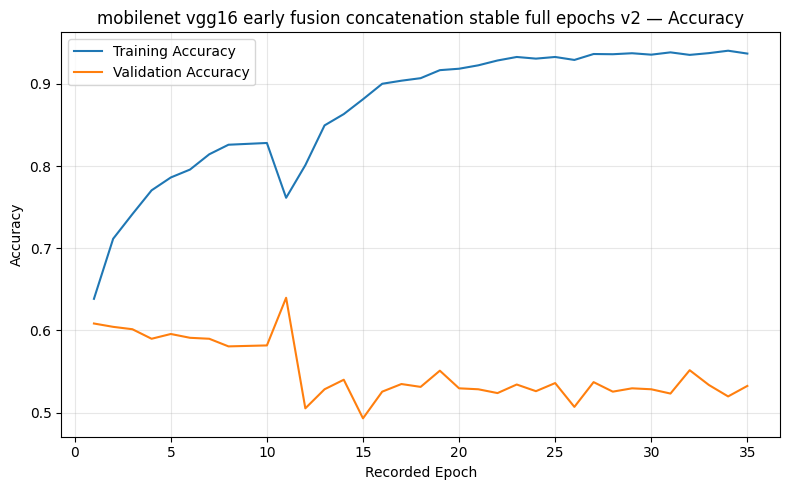

Saved: /content/output/mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2_accuracy.png


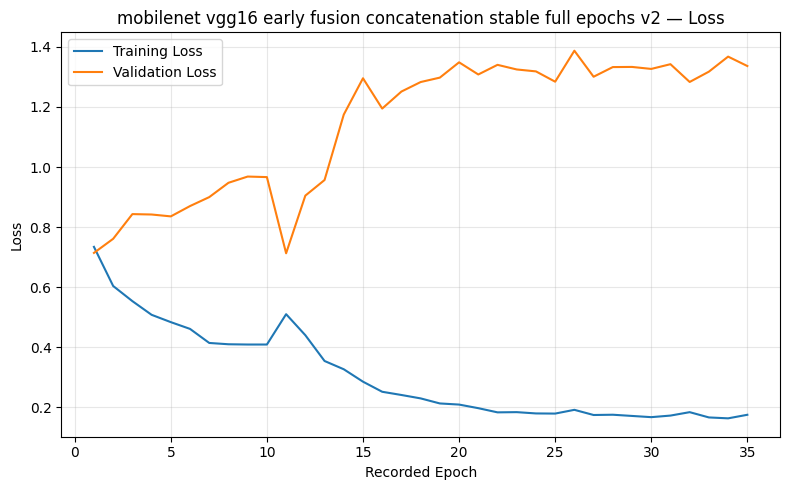

Saved: /content/output/mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2_loss.png


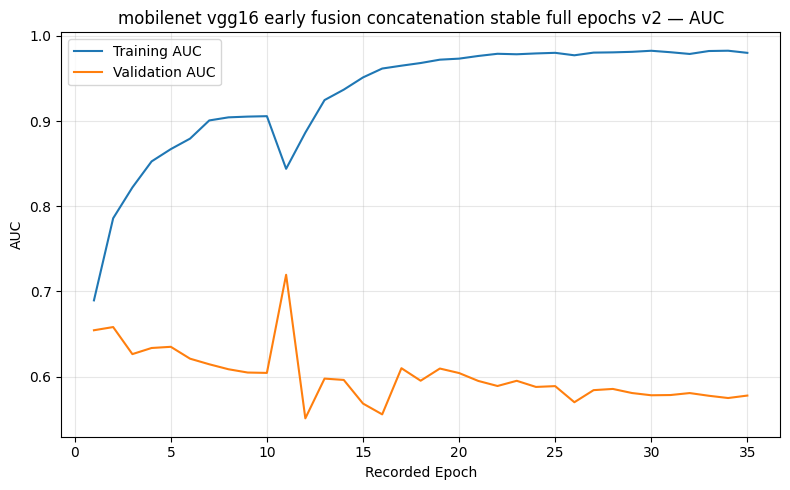

Saved: /content/output/mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2_auc.png
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step
Saved and verified: /content/output/mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2_slice_roc_data.npz
Saved and verified: /content/output/mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2_patient_roc_data.npz


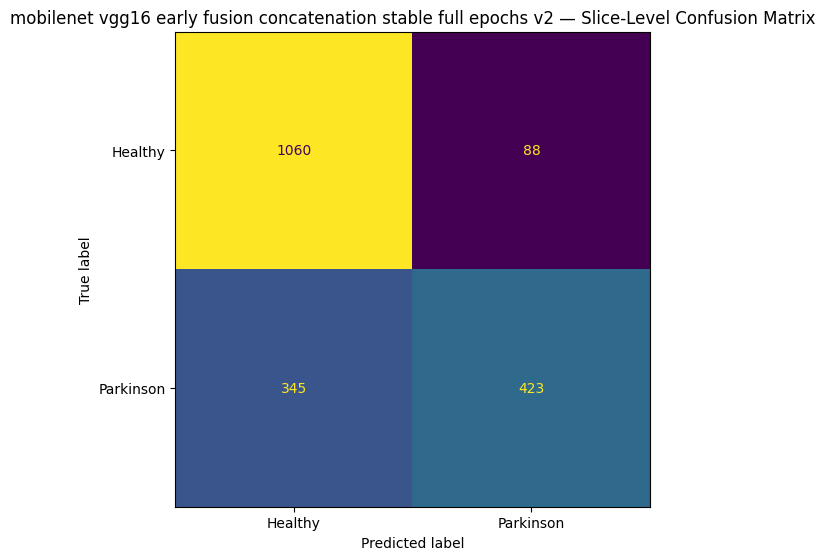

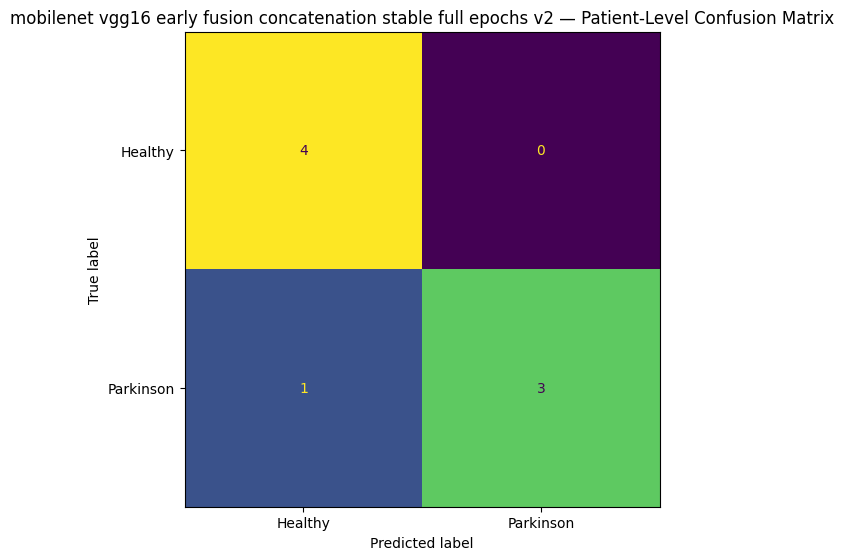

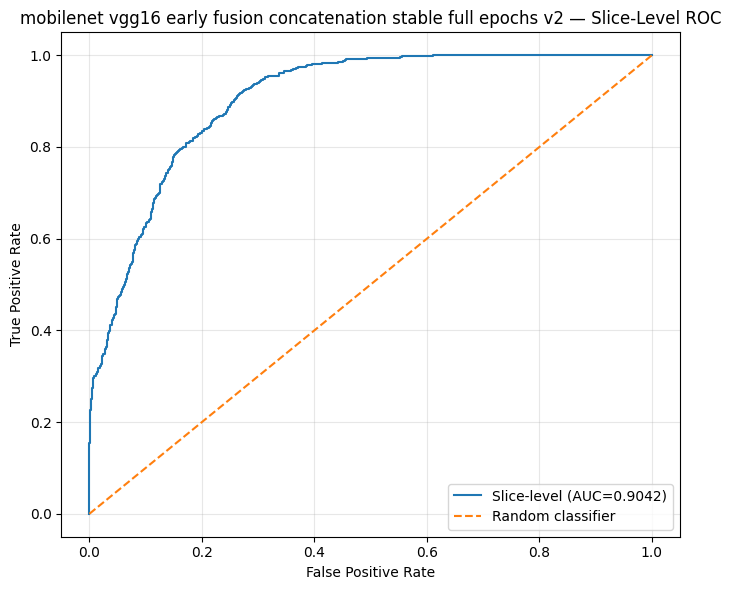

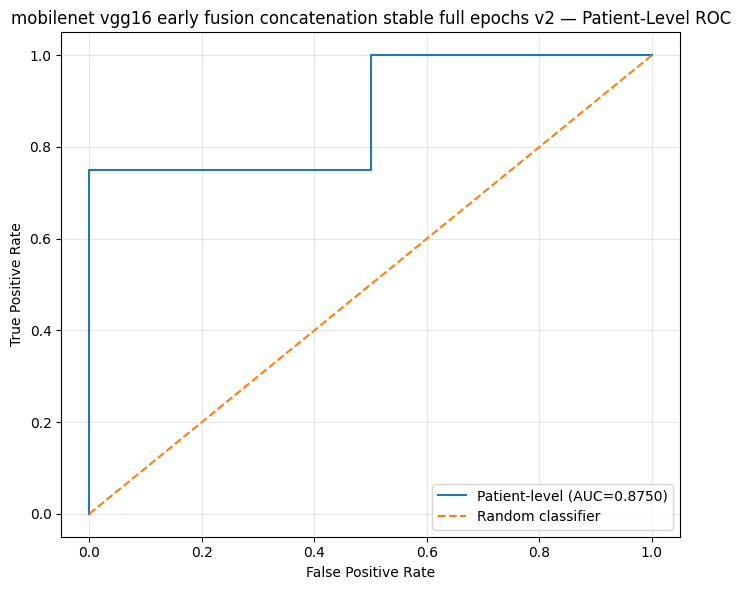


Evaluation complete: mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2
y_true shape: (1916,)
y_prob shape: (1916,)
Probability range: (3.0264318411354907e-05, 0.9970236420631409)
Slice metrics: {'accuracy': 0.774008350730689, 'precision': 0.8277886497064579, 'recall': 0.55078125, 'f1': 0.6614542611415168, 'auc': 0.9042061374854822}
Patient metrics: {'accuracy': 0.875, 'precision': 1.0, 'recall': 0.75, 'f1': 0.8571428571428571, 'auc': 0.875}
Restored from Drive: mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_best.keras
Restored from Drive: mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_history.json
Restored from Drive: mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_training_summary.json


Model: "MobileNetV2_VGG16_Early_Fusion_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_prepro… │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (MobileNetV2Prepro… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocessing │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (VGG16Preprocess)   │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_backbo… │ (None, 7, 7,      │  2,257,984 │ mobilenetv2_prep… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_backbone      │ (None, 7, 7, 512) │ 14,714,688 │ vgg16_preprocess… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_gap     │ (None, 1280)      │          0 │ mobilenetv2_back… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_gap           │ (None, 512)       │          0 │ vgg16_backbone[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_projec… │ (None, 256)       │    327,936 │ mobilenetv2_gap[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_projected     │ (None, 256)       │    131,328 │ vgg16_gap[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_input     │ (None, 512)       │          0 │ mobilenetv2_proj… │
│ (Concatenate)       │                   │            │ vgg16_projected[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_attention_w… │ (None, 2)         │      1,026 │ attention_input[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_attent… │ (None, 1)         │          0 │ branch_attention… │
│ (SelectAttentionWe… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_attention_we… │ (None, 1)         │          0 │ branch_attention… │
│ (SelectAttentionWe… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_mobilenet… │ (None, 256)       │          0 │ mobilenetv2_proj… │
│ (Multiply)          │                   │            │ mobilenetv2_atte… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_vgg16_fea… │ (None, 256)       │          0 │ vgg16_projected[… │
│ (Multiply)          │                   │            │ vgg16_attention_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ early_fusion_atten… │ (None, 256)       │          0 │ weighted_mobilen… │
│ (Add)               │                   │            │ weighted_vgg16_f… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_dense_256 │ (None, 256)       │     65,792 │ early_fusion_att

 Total params: 17,533,315 (66.88 MB)

 Trainable params: 559,875 (2.14 MB)

 Non-trainable params: 16,973,440 (64.75 MB)

                                   Model  Total Parameters  Trainable Parameters  Non-Trainable Parameters
MobileNetV2_VGG16_Early_Fusion_Attention          17533315                559875                  16973440
Saved: /content/output/mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_model_summary.txt
Saved: /content/output/mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_parameters.csv
Restored from Drive: mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_stage1_best.keras
Restored from Drive: mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_head_history.json
Restored from Drive: mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_stage1_metadata.json

Reusing completed Stage 1 model: /content/output/mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_stage1_best.keras

Stage 2: controlled fine-tuning
Configured Stage 2 epochs: 25
Early stopping enabled: False
Detected VGG16 backbone: vgg16_backbone
Detected MobileNetV2

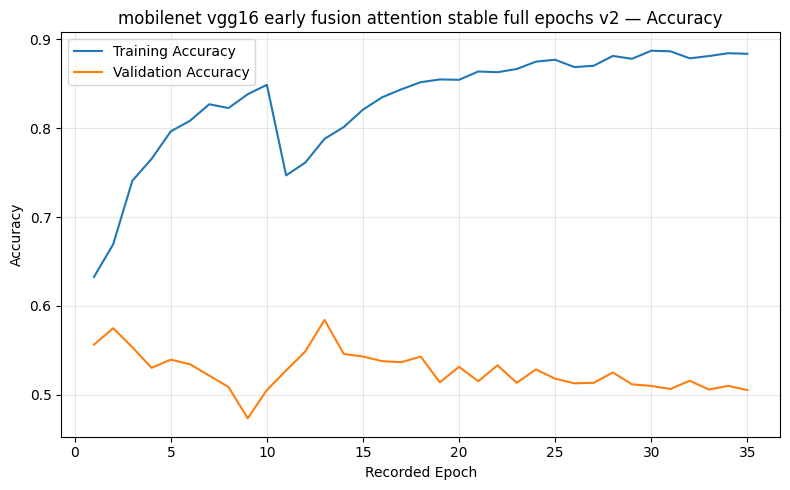

Saved: /content/output/mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_accuracy.png


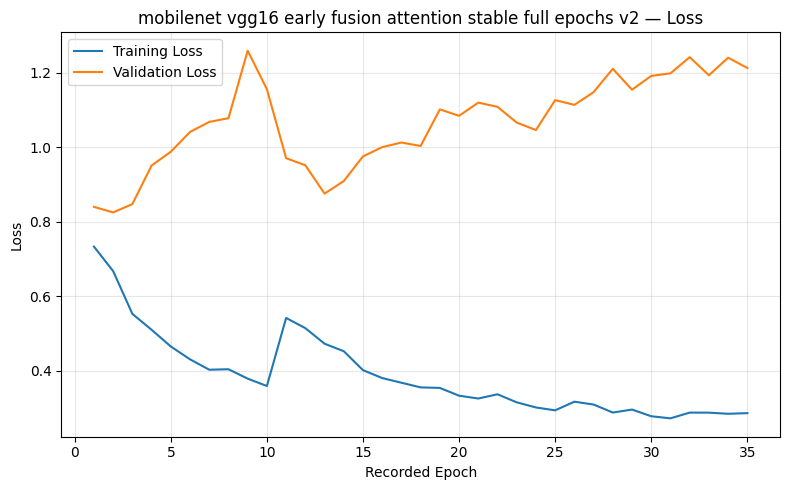

Saved: /content/output/mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_loss.png


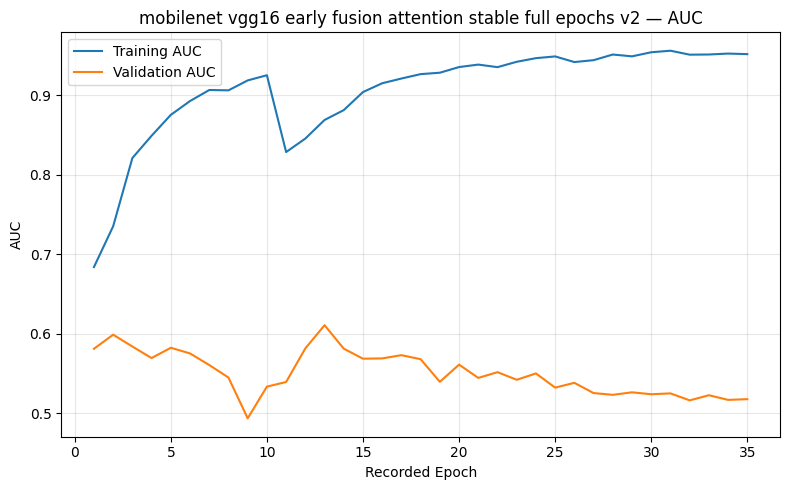

Saved: /content/output/mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_auc.png
240/240 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step
Saved and verified: /content/output/mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_slice_roc_data.npz
Saved and verified: /content/output/mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_patient_roc_data.npz


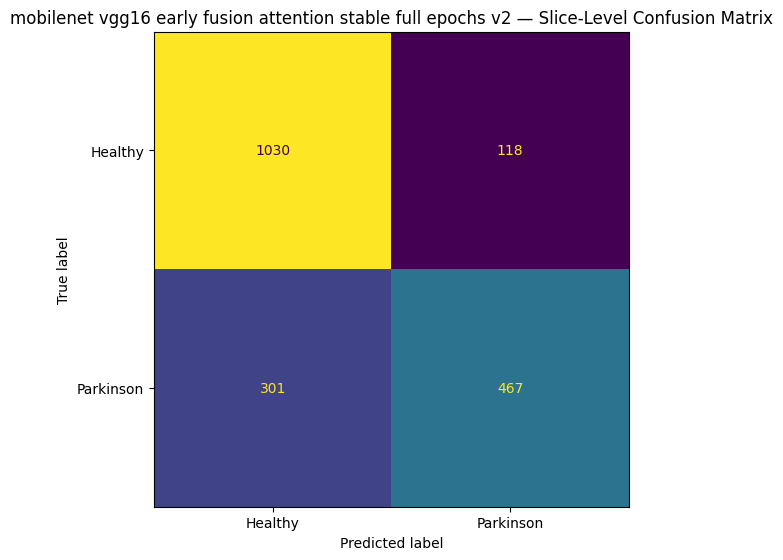

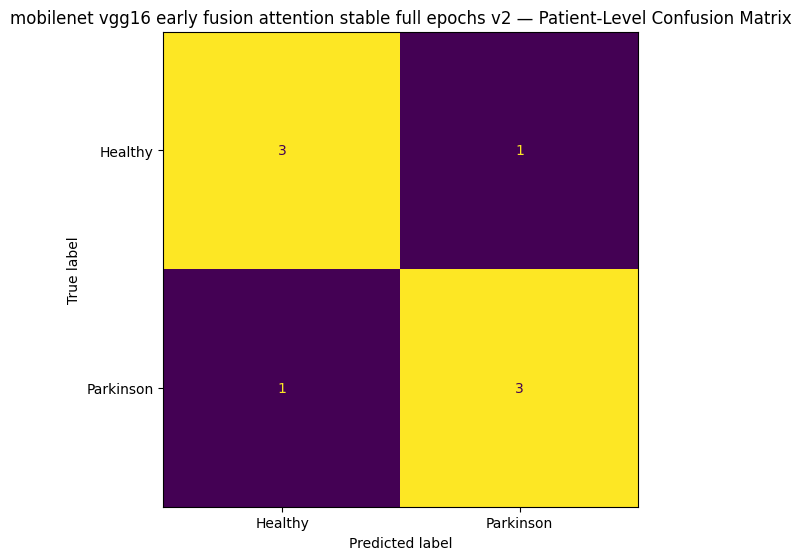

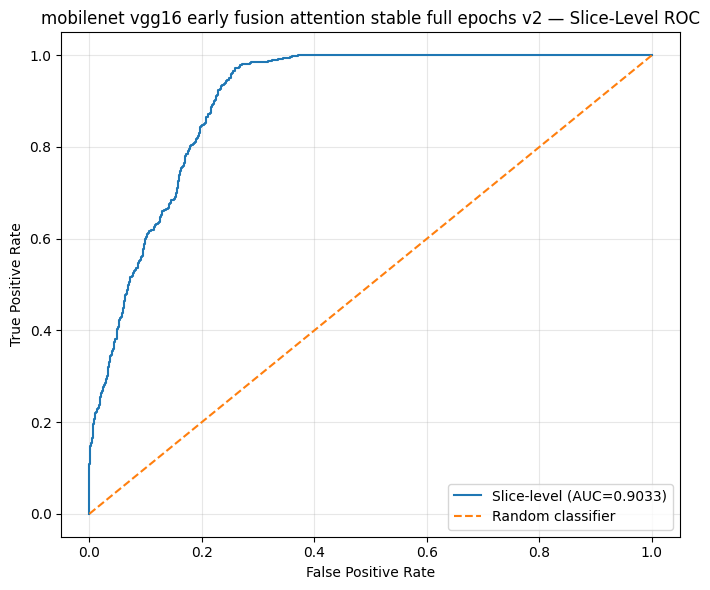

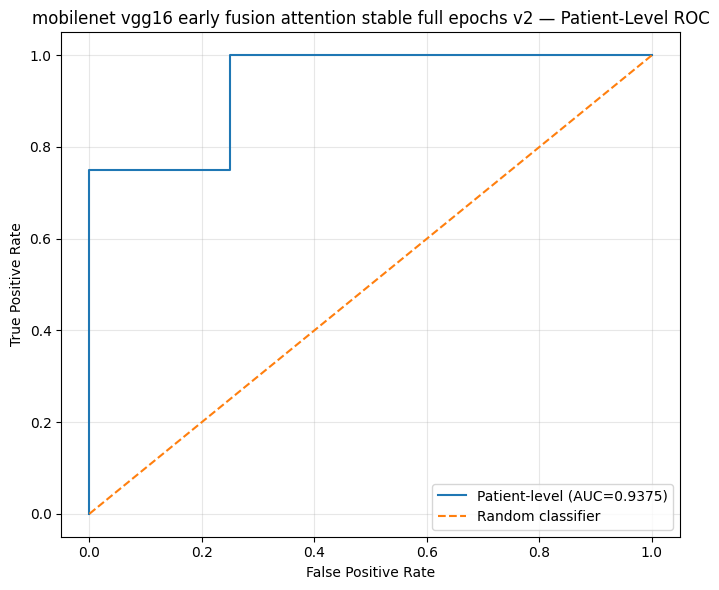


Evaluation complete: mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2
y_true shape: (1916,)
y_prob shape: (1916,)
Probability range: (0.00010519538045627996, 0.9999701976776123)
Slice metrics: {'accuracy': 0.7813152400835073, 'precision': 0.7982905982905983, 'recall': 0.6080729166666666, 'f1': 0.6903178122690318, 'auc': 0.9033475337543554}
Patient metrics: {'accuracy': 0.75, 'precision': 0.75, 'recall': 0.75, 'f1': 0.75, 'auc': 0.9375}

Completed model experiments:
['mobilenet_vgg16_early_fusion_concatenation_stable_full_epochs_v2', 'mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2']


In [ ]:
# ============================================================
# 20. TRAIN AND EVALUATE BOTH EARLY-FUSION MODELS
# ============================================================
def plot_history_metric(
    history,
    metric,
    display_name,
    prefix
):
    train_values = history.get(metric, [])
    validation_values = history.get(
        f"val_{metric}",
        []
    )

    if not train_values or not validation_values:
        print(
            f"Skipping {metric} plot; history unavailable."
        )
        return

    epochs = np.arange(
        1,
        len(train_values) + 1
    )

    figure, axis = plt.subplots(
        figsize=(8, 5)
    )

    axis.plot(
        epochs,
        train_values,
        label=f"Training {display_name}"
    )

    axis.plot(
        epochs,
        validation_values,
        label=f"Validation {display_name}"
    )

    axis.set_xlabel("Recorded Epoch")
    axis.set_ylabel(display_name)
    axis.set_title(
        f"{prefix.replace('_', ' ')} — {display_name}"
    )
    axis.grid(alpha=0.3)
    axis.legend()
    figure.tight_layout()

    save_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_{metric}.png"
    )

    figure.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(figure)

    print("Saved:", save_path)


def run_model_experiment(
    prefix,
    builder_function
):
    restore_completed_artifacts(prefix)

    final_model_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_best.keras"
    )

    if (
        REUSE_COMPLETED_MODELS
        and final_model_path.exists()
    ):
        print(
            "\nLoading completed model:",
            final_model_path
        )
        model = load_fusion_model(
            final_model_path
        )
        history = load_json(
            ROOT_OUTPUT_DIR
            / f"{prefix}_history.json",
            default={}
        )
        training_summary = load_json(
            ROOT_OUTPUT_DIR
            / f"{prefix}_training_summary.json",
            default={}
        )
    else:
        tf.keras.backend.clear_session()
        gc.collect()

        model = builder_function(
            base_trainable=False
        )

        # Test one forward pass before long training.
        dummy_output = model(
            tf.zeros(
                (1, IMG_SIZE, IMG_SIZE, 3),
                dtype=tf.float32
            ),
            training=False
        )

        if (
            dummy_output.shape != (1, 1)
            or not np.all(
                np.isfinite(
                    dummy_output.numpy()
                )
            )
        ):
            raise RuntimeError(
                "Model forward-pass validation failed."
            )

        model.summary()
        save_model_information(
            model,
            prefix
        )

        (
            model,
            history,
            training_summary
        ) = train_two_stage_model(
            model,
            prefix
        )

    for metric, name in [
        ("accuracy", "Accuracy"),
        ("loss", "Loss"),
        ("auc", "AUC")
    ]:
        plot_history_metric(
            history,
            metric,
            name,
            prefix
        )

    result = evaluate_fusion_model(
        model,
        prefix
    )

    result["training_summary"] = (
        training_summary
    )

    return result


all_model_results = {}
trained_model_paths = {}

if RUN_CONCATENATION_MODEL:
    concat_results = run_model_experiment(
        CONCAT_PREFIX,
        build_concat_model
    )

    all_model_results[
        CONCAT_PREFIX
    ] = concat_results

    trained_model_paths[
        CONCAT_PREFIX
    ] = concat_results["model_path"]

    gc.collect()

if RUN_ATTENTION_MODEL:
    attention_results = run_model_experiment(
        ATTENTION_PREFIX,
        build_attention_model
    )

    all_model_results[
        ATTENTION_PREFIX
    ] = attention_results

    trained_model_paths[
        ATTENTION_PREFIX
    ] = attention_results["model_path"]

    gc.collect()

if not all_model_results:
    raise RuntimeError(
        "No model ran. Enable at least one model."
    )

print("\nCompleted model experiments:")
print(list(all_model_results.keys()))

### 20. Train and Evaluate Both Early-Fusion Models
This is the main execution block for the model experiments. It defines `run_model_experiment`, which handles the entire workflow for a given model architecture (concatenation or attention). This includes:

1.  **Model Loading/Initialization**: It attempts to reuse previously completed models if `REUSE_COMPLETED_MODELS` is true and the model exists locally. Otherwise, it clears the Keras session, builds a new model using the provided `builder_function`, and performs a quick forward-pass diagnostic.
2.  **Model Training**: Calls `train_two_stage_model` to execute the two-stage training process (head training then fine-tuning), leveraging all the stable training and recovery helpers defined earlier.
3.  **Plotting Training Curves**: Generates and saves training/validation curves for loss, accuracy, and AUC.
4.  **Model Evaluation**: Calls `evaluate_fusion_model` to perform comprehensive slice-level and patient-level evaluation on the test set.

The cell then conditionally runs the experiments for the concatenation and/or attention models based on `RUN_CONCATENATION_MODEL` and `RUN_ATTENTION_MODEL` flags, storing their results in `all_model_results`.

In [ ]:
# ============================================================
# 21. COMPARE MODELS AND CREATE STANDARD ROC NPZ ALIASES
# ============================================================
if not all_model_results:
    raise RuntimeError(
        "No completed model results are available."
    )

comparison_df = pd.DataFrame([
    result["metrics"]
    for result in all_model_results.values()
])

comparison_path = (
    ROOT_OUTPUT_DIR
    / "mobilenet_vgg16_early_fusion_model_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

display(comparison_df)

ranking_columns = [
    "Patient ROC AUC",
    "Patient F1",
    "Patient Accuracy"
]

ranked_df = comparison_df.sort_values(
    by=ranking_columns,
    ascending=False,
    na_position="last"
).reset_index(drop=True)

best_prefix = str(
    ranked_df.loc[0, "Model Prefix"]
)

best_result = all_model_results[
    best_prefix
]

best_model_path = Path(
    best_result["model_path"]
)

if not best_model_path.exists():
    raise FileNotFoundError(
        f"Best model missing: {best_model_path}"
    )

with np.load(
    best_result["slice_npz_path"]
) as slice_data:
    standard_slice_npz = (
        ROOT_OUTPUT_DIR
        / "mobilenet_vgg16_early_fusion_roc_data.npz"
    )

    np.savez_compressed(
        standard_slice_npz,
        y_true=slice_data["y_true"],
        y_prob=slice_data["y_prob"]
    )

with np.load(
    best_result["patient_npz_path"]
) as patient_data:
    standard_patient_npz = (
        ROOT_OUTPUT_DIR
        / (
            "mobilenet_vgg16_early_fusion_"
            "patient_roc_data.npz"
        )
    )

    np.savez_compressed(
        standard_patient_npz,
        y_true=patient_data["y_true"],
        y_prob=patient_data["y_prob"]
    )

best_summary = {
    "best_prefix": best_prefix,
    "best_model_path": str(
        best_model_path
    ),
    "ranking_columns": ranking_columns,
    "metrics": best_result["metrics"],
    "standard_slice_roc_npz": str(
        standard_slice_npz
    ),
    "standard_patient_roc_npz": str(
        standard_patient_npz
    )
}

save_json(
    best_summary,
    ROOT_OUTPUT_DIR
    / "mobilenet_vgg16_best_early_fusion_summary.json"
)

print("Best early-fusion model:", best_prefix)
print("Best model path:", best_model_path)
print("Standard slice ROC NPZ:", standard_slice_npz)
print("Standard patient ROC NPZ:", standard_patient_npz)

,Model Prefix,Slice Accuracy,Slice Precision,Slice Recall,Slice F1,Slice ROC AUC,Patient Accuracy,Patient Precision,Patient Recall,Patient F1,Patient ROC AUC,Test Slices,Test Patients
0,mobilenet_vgg16_early_fusion_concatenation_sta...,0.774008,0.827789,0.550781,0.661454,0.904206,0.875,1.00,0.75,0.857143,0.8750,1916,8
1,mobilenet_vgg16_early_fusion_attention_stable_...,0.781315,0.798291,0.608073,0.690318,0.903348,0.750,0.75,0.75,0.750000,0.9375,1916,8


Best early-fusion model: mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2
Best model path: /content/output/mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_best.keras
Standard slice ROC NPZ: /content/output/mobilenet_vgg16_early_fusion_roc_data.npz
Standard patient ROC NPZ: /content/output/mobilenet_vgg16_early_fusion_patient_roc_data.npz


### 21. Compare Models and Create Standard ROC NPZ Aliases
After both fusion models have been trained and evaluated, this section compares their performance. It compiles a DataFrame of key metrics (especially patient-level ROC AUC, F1, and Accuracy) for all models, saves it as a CSV, and then identifies the best-performing model based on these metrics.

For the best model, it creates standard aliases for its slice-level and patient-level ROC data NPZ files. These standardized files make it easier to locate and use the ROC data of the top-performing model for further analysis or visualization, ensuring consistency regardless of which model ultimately performed best.

## Corrected branch-wise Grad-CAM for the selected best model

Run the following cells after model training and evaluation. They can
also be rerun after a kernel reset, provided that the completed model,
comparison CSV and slice-prediction CSV are available in the output
directory.

### 23. Reload the Best Completed Model for Grad-CAM
This cell is designed to reload the best-performing model after training and evaluation have completed. This is particularly useful if the kernel is reset, allowing Grad-CAM analysis to proceed without retraining the models. It recovers information about the best model (prefix, path, and slice predictions) from the saved comparison CSV and then loads the corresponding Keras model. It also identifies the VGG16 and MobileNetV2 backbones within the loaded model, which are necessary for the Grad-CAM computation.

In [ ]:
# ============================================================
# 23. RELOAD THE BEST COMPLETED MODEL FOR GRAD-CAM
# ============================================================
def recover_best_model_information():
    comparison_path = (
        ROOT_OUTPUT_DIR
        / "mobilenet_vgg16_early_fusion_model_comparison.csv"
    )

    if not comparison_path.exists():
        raise FileNotFoundError(
            "The model-comparison CSV is missing. Run the training and "
            "evaluation cells before Grad-CAM. Expected: "
            f"{comparison_path}"
        )

    recovered_comparison = pd.read_csv(
        comparison_path
    )

    required_columns = {
        "Model Prefix",
        "Patient ROC AUC",
        "Patient F1",
        "Patient Accuracy"
    }

    missing_columns = (
        required_columns
        - set(recovered_comparison.columns)
    )

    if missing_columns:
        raise ValueError(
            "The model-comparison CSV is missing columns: "
            f"{sorted(missing_columns)}"
        )

    recovered_ranked = recovered_comparison.sort_values(
        by=[
            "Patient ROC AUC",
            "Patient F1",
            "Patient Accuracy"
        ],
        ascending=False,
        na_position="last"
    ).reset_index(drop=True)

    recovered_prefix = str(
        recovered_ranked.loc[0, "Model Prefix"]
    )

    recovered_model_path = (
        ROOT_OUTPUT_DIR
        / f"{recovered_prefix}_best.keras"
    )

    recovered_predictions_path = (
        ROOT_OUTPUT_DIR
        / f"{recovered_prefix}_slice_predictions.csv"
    )

    if not recovered_model_path.exists():
        raise FileNotFoundError(
            f"Best model file is missing: {recovered_model_path}"
        )

    if not recovered_predictions_path.exists():
        raise FileNotFoundError(
            "Best-model slice predictions are missing: "
            f"{recovered_predictions_path}"
        )

    recovered_predictions = pd.read_csv(
        recovered_predictions_path
    )

    return (
        recovered_prefix,
        recovered_model_path,
        recovered_predictions
    )


best_prefix, best_model_path, best_prediction_df = (
    recover_best_model_information()
)

best_model = load_fusion_model(
    best_model_path
)

vgg_backbone, mobile_backbone = (
    find_fusion_backbones(best_model)
)

print("Selected best model:", best_prefix)
print("Loaded model:", best_model.name)
print("Model path:", best_model_path)
print("VGG16 backbone:", vgg_backbone.name)
print("MobileNetV2 backbone:", mobile_backbone.name)
print("Best-model loading check: PASSED")

Detected VGG16 backbone: vgg16_backbone
Detected MobileNetV2 backbone: mobilenetv2_backbone
Selected best model: mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2
Loaded model: MobileNetV2_VGG16_Early_Fusion_Attention
Model path: /content/output/mobilenet_vgg16_early_fusion_attention_stable_full_epochs_v2_best.keras
VGG16 backbone: vgg16_backbone
MobileNetV2 backbone: mobilenetv2_backbone
Best-model loading check: PASSED


### 24. Keras 3–Safe Nested-Backbone Grad-CAM
This section implements the Keras 3-safe Gradient-weighted Class Activation Mapping (Grad-CAM) technique for interpreting the early fusion models. Grad-CAM visually highlights the regions in the input image that were most important for the model's prediction.

Key components:

*   `VGG_LAYER_CANDIDATES`, `MOBILE_LAYER_CANDIDATES`: Lists of potential final convolutional layers for each backbone to probe for Grad-CAM.
*   `valid_spatial_layer_names`: Identifies suitable convolutional layers with 4D output for Grad-CAM.
*   `build_backbone_probe`: Creates a sub-model (probe) for each backbone to extract features and gradients from a specific layer.
*   `forward_saved_fusion_head`: Reconstructs the forward pass of the trained fusion head in eager mode to get predictions.
*   `normalize_heatmap`: Processes the raw heatmap to ensure it's normalized and handles cases where gradients might be zero or non-finite.
*   `calculate_branch_gradcam_pair`: The core Grad-CAM logic, which computes gradients with respect to the target class for both VGG16 and MobileNetV2 branches, generates heatmaps, and performs sanity checks on gradients.
*   `load_rgb_image_for_gradcam`: Utility to load and preprocess images for Grad-CAM.
*   `resize_heatmap`, `colored_heatmap`, `overlay_heatmap`: Functions for post-processing and visualizing heatmaps over the original images.

In [ ]:
# ============================================================
# 24. KERAS 3–SAFE NESTED-BACKBONE GRAD-CAM
# ============================================================
VGG_LAYER_CANDIDATES = [
    "block5_conv3",
    "block5_conv2",
    "block5_conv1",
    "block4_conv3",
    "block4_conv2"
]

MOBILE_LAYER_CANDIDATES = [
    "Conv_1",
    "block_16_project",
    "block_15_project",
    "block_14_project",
    "block_13_project"
]


def valid_spatial_layer_names(backbone, preferred_names):
    available = {
        layer.name: layer
        for layer in backbone.layers
    }

    selected = []

    for layer_name in preferred_names:
        layer = available.get(layer_name)

        if layer is None:
            continue

        try:
            output_rank = len(layer.output.shape)
        except Exception:
            output_rank = None

        if output_rank == 4:
            selected.append(layer_name)

    if selected:
        return selected

    fallback = []

    for layer in reversed(backbone.layers):
        try:
            output_rank = len(layer.output.shape)
        except Exception:
            output_rank = None

        if output_rank == 4:
            fallback.append(layer.name)

        if len(fallback) >= 5:
            break

    if not fallback:
        raise ValueError(
            f"No four-dimensional spatial layer was found in "
            f"{backbone.name}."
        )

    return fallback


def build_backbone_probe(backbone, target_layer_name):
    target_layer = backbone.get_layer(
        target_layer_name
    )

    probe = keras.Model(
        inputs=backbone.input,
        outputs=[
            target_layer.output,
            backbone.output
        ],
        name=(
            f"{backbone.name}_"
            f"{target_layer_name}_gradcam_probe"
        )
    )

    return probe


def call_layer_inference(layer, inputs):
    try:
        return layer(
            inputs,
            training=False
        )
    except TypeError:
        return layer(inputs)


def forward_saved_fusion_head(
    model,
    vgg_feature_maps,
    mobile_feature_maps
):
    vgg_vector = call_layer_inference(
        model.get_layer("vgg16_gap"),
        vgg_feature_maps
    )

    mobile_vector = call_layer_inference(
        model.get_layer("mobilenetv2_gap"),
        mobile_feature_maps
    )

    layer_names = {
        layer.name
        for layer in model.layers
    }

    if "early_fusion_concatenation" in layer_names:
        x = model.get_layer(
            "early_fusion_concatenation"
        )([
            mobile_vector,
            vgg_vector
        ])

        for layer_name in [
            "concat_dense_512",
            "concat_bn_512",
            "concat_dropout_512",
            "concat_dense_256",
            "concat_bn_256",
            "concat_dropout_256",
            "concat_dense_128",
            "concat_bn_128",
            "concat_dropout_128",
            "prediction"
        ]:
            x = call_layer_inference(
                model.get_layer(layer_name),
                x
            )

        return x

    required_attention_layers = {
        "vgg16_projected",
        "mobilenetv2_projected",
        "attention_input",
        "branch_attention_weights",
        "vgg16_attention_weight",
        "mobilenetv2_attention_weight",
        "weighted_vgg16_features",
        "weighted_mobilenetv2_features",
        "early_fusion_attention",
        "prediction"
    }

    missing_attention_layers = (
        required_attention_layers
        - layer_names
    )

    if missing_attention_layers:
        raise ValueError(
            "The loaded model is neither the expected concatenation "
            "model nor the expected attention model. Missing layers: "
            f"{sorted(missing_attention_layers)}"
        )

    vgg_projected = call_layer_inference(
        model.get_layer("vgg16_projected"),
        vgg_vector
    )

    mobile_projected = call_layer_inference(
        model.get_layer("mobilenetv2_projected"),
        mobile_vector
    )

    attention_input = model.get_layer(
        "attention_input"
    )([
        mobile_projected,
        vgg_projected
    ])

    attention_weights = call_layer_inference(
        model.get_layer("branch_attention_weights"),
        attention_input
    )

    mobile_weight = call_layer_inference(
        model.get_layer("mobilenetv2_attention_weight"),
        attention_weights
    )

    vgg_weight = call_layer_inference(
        model.get_layer("vgg16_attention_weight"),
        attention_weights
    )

    weighted_mobile = model.get_layer(
        "weighted_mobilenetv2_features"
    )([
        mobile_projected,
        mobile_weight
    ])

    weighted_vgg = model.get_layer(
        "weighted_vgg16_features"
    )([
        vgg_projected,
        vgg_weight
    ])

    x = model.get_layer(
        "early_fusion_attention"
    )([
        weighted_mobile,
        weighted_vgg
    ])

    for layer_name in [
        "attention_dense_256",
        "attention_bn_256",
        "attention_dropout_256",
        "attention_dense_128",
        "attention_bn_128",
        "attention_dropout_128",
        "prediction"
    ]:
        x = call_layer_inference(
            model.get_layer(layer_name),
            x
        )

    return x


def normalize_heatmap(feature_maps, gradients):
    if gradients is None:
        raise RuntimeError(
            "GradientTape returned None gradients."
        )

    gradients = tf.cast(
        gradients,
        tf.float32
    )

    feature_maps = tf.cast(
        feature_maps,
        tf.float32
    )

    if not bool(
        tf.reduce_all(
            tf.math.is_finite(gradients)
        )
    ):
        raise FloatingPointError(
            "Grad-CAM gradients contain NaN or Inf."
        )

    gradient_norm = float(
        tf.linalg.global_norm([gradients]).numpy()
    )

    if gradient_norm <= 1e-12:
        raise RuntimeError(
            "Grad-CAM gradient norm is zero."
        )

    channel_weights = tf.reduce_mean(
        gradients,
        axis=(1, 2),
        keepdims=True
    )

    heatmap = tf.reduce_sum(
        channel_weights * feature_maps,
        axis=-1
    )[0]

    heatmap = tf.nn.relu(heatmap)

    maximum = float(
        tf.reduce_max(heatmap).numpy()
    )

    if maximum <= 1e-12:
        # A signed absolute map is a safe diagnostic fallback for
        # very confident sigmoid predictions whose positive ReLU map
        # is empty.
        signed_map = tf.reduce_sum(
            channel_weights * feature_maps,
            axis=-1
        )[0]

        heatmap = tf.abs(signed_map)
        maximum = float(
            tf.reduce_max(heatmap).numpy()
        )

    if maximum <= 1e-12:
        raise RuntimeError(
            "The Grad-CAM heatmap remained zero."
        )

    heatmap = (
        heatmap / maximum
    ).numpy().astype(np.float32)

    return heatmap, gradient_norm


def calculate_branch_gradcam_pair(
    model,
    image_batch,
    target_class
):
    if target_class not in (0, 1):
        raise ValueError(
            "target_class must be 0 or 1."
        )

    vgg_backbone, mobile_backbone = (
        find_fusion_backbones(model)
    )

    vgg_layer_names = valid_spatial_layer_names(
        vgg_backbone,
        VGG_LAYER_CANDIDATES
    )

    mobile_layer_names = valid_spatial_layer_names(
        mobile_backbone,
        MOBILE_LAYER_CANDIDATES
    )

    attempt_errors = []

    for vgg_layer_name in vgg_layer_names:
        for mobile_layer_name in mobile_layer_names:
            try:
                vgg_probe = build_backbone_probe(
                    vgg_backbone,
                    vgg_layer_name
                )

                mobile_probe = build_backbone_probe(
                    mobile_backbone,
                    mobile_layer_name
                )

                vgg_input = vgg16_preprocess(
                    tf.cast(
                        image_batch,
                        tf.float32
                    )
                )

                mobile_input = mobilenet_preprocess(
                    tf.cast(
                        image_batch,
                        tf.float32
                    )
                )

                with tf.GradientTape(
                    persistent=True
                ) as tape:
                    (
                        vgg_conv_maps,
                        vgg_final_maps
                    ) = vgg_probe(
                        vgg_input,
                        training=False
                    )

                    (
                        mobile_conv_maps,
                        mobile_final_maps
                    ) = mobile_probe(
                        mobile_input,
                        training=False
                    )

                    tape.watch(vgg_conv_maps)
                    tape.watch(mobile_conv_maps)

                    probability = (
                        forward_saved_fusion_head(
                            model,
                            vgg_final_maps,
                            mobile_final_maps
                        )
                    )[:, 0]

                    target_score = (
                        probability
                        if target_class == 1
                        else 1.0 - probability
                    )

                vgg_gradients = tape.gradient(
                    target_score,
                    vgg_conv_maps
                )

                mobile_gradients = tape.gradient(
                    target_score,
                    mobile_conv_maps
                )

                del tape

                (
                    vgg_heatmap,
                    vgg_gradient_norm
                ) = normalize_heatmap(
                    vgg_conv_maps,
                    vgg_gradients
                )

                (
                    mobile_heatmap,
                    mobile_gradient_norm
                ) = normalize_heatmap(
                    mobile_conv_maps,
                    mobile_gradients
                )

                predicted_probability = float(
                    probability[0].numpy()
                )

                return {
                    "vgg_heatmap": vgg_heatmap,
                    "mobile_heatmap": mobile_heatmap,
                    "vgg_layer": vgg_layer_name,
                    "mobile_layer": mobile_layer_name,
                    "vgg_gradient_norm": vgg_gradient_norm,
                    "mobile_gradient_norm": mobile_gradient_norm,
                    "predicted_probability": predicted_probability
                }

            except Exception as error:
                attempt_errors.append(
                    {
                        "vgg_layer": vgg_layer_name,
                        "mobile_layer": mobile_layer_name,
                        "error": str(error)
                    }
                )

    raise RuntimeError(
        "Grad-CAM failed for every tested layer pair. "
        f"Attempts: {attempt_errors}"
    )


def load_rgb_image_for_gradcam(image_path):
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(
            f"Grad-CAM image is missing: {image_path}"
        )

    image = keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        color_mode="rgb"
    )

    image_array = keras.utils.img_to_array(
        image
    ).astype(np.float32)

    return image_array


def resize_heatmap(heatmap, height, width):
    resized = tf.image.resize(
        heatmap[
            np.newaxis,
            ...,
            np.newaxis
        ],
        size=(height, width),
        method="bilinear"
    )[0, ..., 0].numpy()

    return np.clip(
        resized,
        0.0,
        1.0
    ).astype(np.float32)


def colored_heatmap(heatmap):
    return (
        plt.colormaps["jet"](heatmap)[..., :3]
        .astype(np.float32)
    )


def overlay_heatmap(
    original_image,
    heatmap_rgb,
    alpha=0.40
):
    original = (
        original_image.astype(np.float32)
        / 255.0
    )

    return np.clip(
        (1.0 - alpha) * original
        + alpha * heatmap_rgb,
        0.0,
        1.0
    )

### 25. Generate and Verify Four Paper-Ready Grad-CAM Panels
This cell orchestrates the generation of Grad-CAM visualizations for representative images. It selects two 'Healthy' and two 'Parkinson' images, preferring central and confident slices from distinct patients. For each selected image, it:

1.  Loads the image.
2.  Calculates Grad-CAM heatmaps for both VGG16 and MobileNetV2 branches, as well as a combined heatmap.
3.  Generates four-panel plots showing the original image, VGG16 Grad-CAM, MobileNetV2 Grad-CAM, and the combined heatmap overlay.
4.  Saves these visualizations as PNG files and raw heatmap data as NPZ files.
5.  Performs rigorous verification on the saved files (existence, size, NPZ key checks, heatmap validity) to ensure high quality and integrity.

A summary DataFrame of all generated Grad-CAM records is saved as a CSV, and final checks ensure that all required Grad-CAM figures exist and are valid.

Detected VGG16 backbone: vgg16_backbone
Detected MobileNetV2 backbone: mobilenetv2_backbone


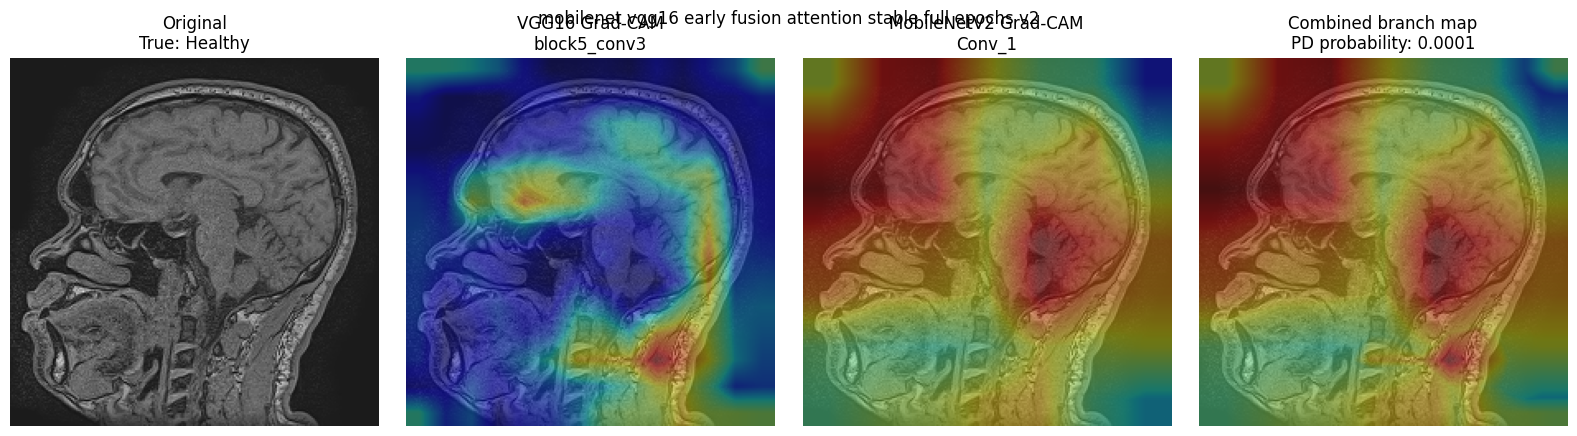

Saved and verified: /content/output/mobilenet_vgg16_early_fusion_gradcam_healthy_1.png
Saved and verified: /content/output/mobilenet_vgg16_early_fusion_gradcam_healthy_1.npz
Detected VGG16 backbone: vgg16_backbone
Detected MobileNetV2 backbone: mobilenetv2_backbone


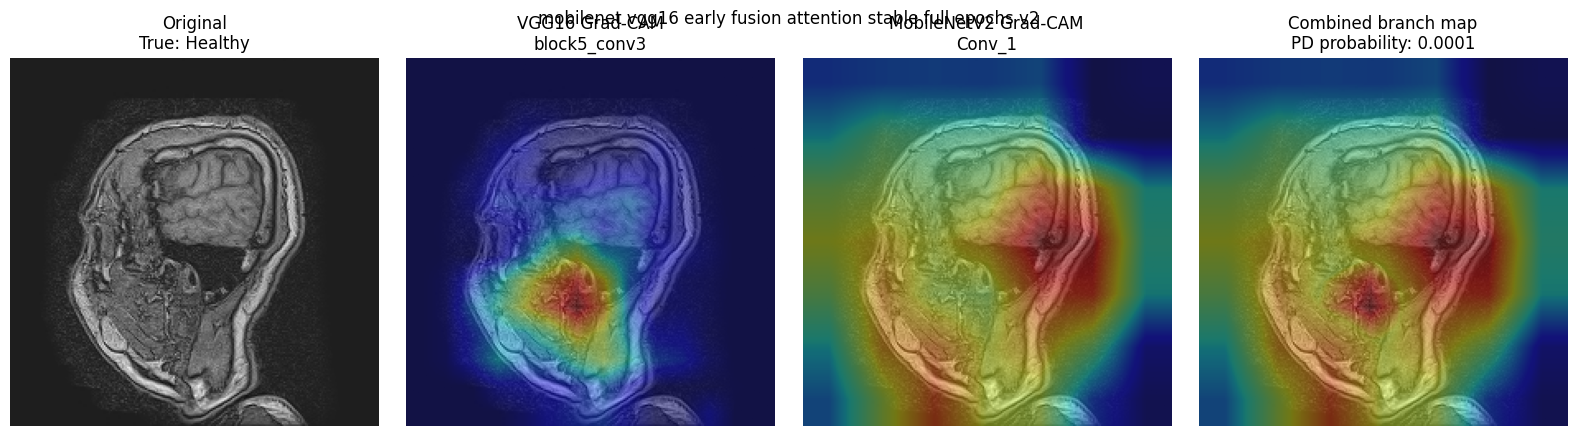

Saved and verified: /content/output/mobilenet_vgg16_early_fusion_gradcam_healthy_2.png
Saved and verified: /content/output/mobilenet_vgg16_early_fusion_gradcam_healthy_2.npz
Detected VGG16 backbone: vgg16_backbone
Detected MobileNetV2 backbone: mobilenetv2_backbone


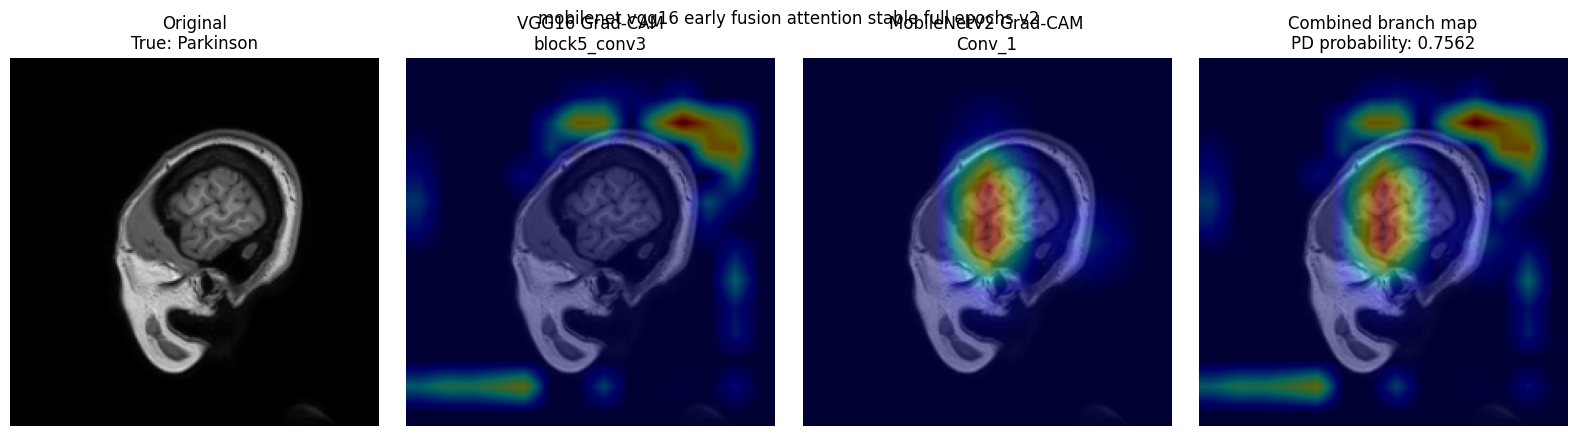

Saved and verified: /content/output/mobilenet_vgg16_early_fusion_gradcam_parkinson_1.png
Saved and verified: /content/output/mobilenet_vgg16_early_fusion_gradcam_parkinson_1.npz
Detected VGG16 backbone: vgg16_backbone
Detected MobileNetV2 backbone: mobilenetv2_backbone


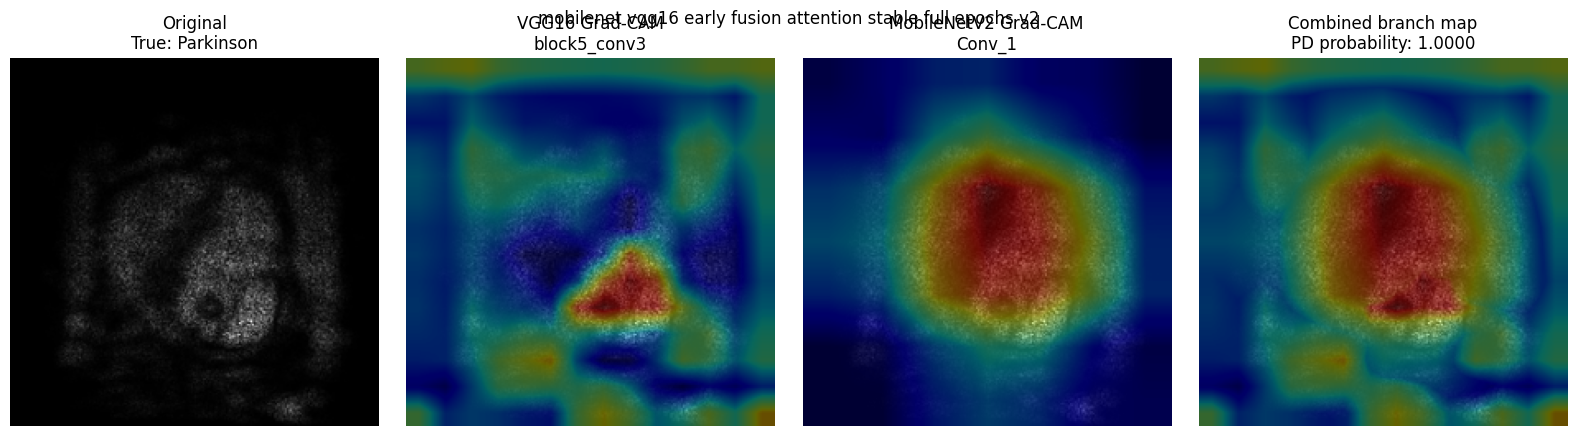

Saved and verified: /content/output/mobilenet_vgg16_early_fusion_gradcam_parkinson_2.png
Saved and verified: /content/output/mobilenet_vgg16_early_fusion_gradcam_parkinson_2.npz


,class_name,sample_number,patient_id,image_path,predicted_probability,vgg_layer,mobile_layer,vgg_gradient_norm,mobile_gradient_norm,png_path,npz_path,status
0,healthy,1,162905,/content/Parkinson_dataset_unzip_here/Parkinso...,0.000106,block5_conv3,Conv_1,7.539877e-12,0.000081,/content/output/mobilenet_vgg16_early_fusion_g...,/content/output/mobilenet_vgg16_early_fusion_g...,saved_and_verified
1,healthy,2,149005,/content/Parkinson_dataset_unzip_here/Parkinso...,0.000143,block5_conv3,Conv_1,4.994446e-12,0.000151,/content/output/mobilenet_vgg16_early_fusion_g...,/content/output/mobilenet_vgg16_early_fusion_g...,saved_and_verified
2,parkinson,1,101179,/content/Parkinson_dataset_unzip_here/Parkinso...,0.756201,block5_conv3,Conv_1,1.059465e-08,0.173593,/content/output/mobilenet_vgg16_early_fusion_g...,/content/output/mobilenet_vgg16_early_fusion_g...,saved_and_verified
3,parkinson,2,101295,/content/Parkinson_dataset_unzip_here/Parkinso...,0.999972,block5_conv3,Conv_1,1.478488e-11,0.000035,/content/output/mobilenet_vgg16_early_fusion_g...,/content/output/mobilenet_vgg16_early_fusion_g...,saved_and_verified


All four Grad-CAM figures exist and passed verification.
Grad-CAM summary: /content/output/mobilenet_vgg16_early_fusion_gradcam_summary.csv


In [ ]:
# ============================================================
# 25. GENERATE AND VERIFY FOUR PAPER-READY GRAD-CAM PANELS
# ============================================================
required_prediction_columns = {
    "image_path",
    "patient_id",
    "label",
    "predicted_probability",
    "correct"
}

missing_prediction_columns = (
    required_prediction_columns
    - set(best_prediction_df.columns)
)

if missing_prediction_columns:
    raise ValueError(
        "The prediction CSV is missing columns required for "
        f"Grad-CAM: {sorted(missing_prediction_columns)}"
    )

candidate_df = best_prediction_df.copy()

candidate_df["label"] = pd.to_numeric(
    candidate_df["label"],
    errors="raise"
).astype(int)

candidate_df["predicted_probability"] = pd.to_numeric(
    candidate_df["predicted_probability"],
    errors="raise"
).astype(float)

candidate_df["correct"] = (
    candidate_df["correct"]
    .astype(str)
    .str.lower()
    .map({
        "true": True,
        "false": False,
        "1": True,
        "0": False
    })
    .fillna(
        candidate_df["correct"].astype(bool)
    )
)

candidate_df = candidate_df[
    candidate_df["correct"] == True
].copy()

candidate_df["display_confidence"] = np.where(
    candidate_df["label"] == 1,
    candidate_df["predicted_probability"],
    1.0 - candidate_df["predicted_probability"]
)

# Prefer one central and confident slice from a distinct patient.
if "slice_index" in candidate_df.columns:
    candidate_df["slice_index"] = pd.to_numeric(
        candidate_df["slice_index"],
        errors="coerce"
    )

    median_slice = candidate_df.groupby(
        "patient_id"
    )["slice_index"].transform("median")

    candidate_df["central_distance"] = (
        candidate_df["slice_index"]
        - median_slice
    ).abs()

    candidate_df["central_distance"] = (
        candidate_df["central_distance"]
        .fillna(np.inf)
    )
else:
    candidate_df["central_distance"] = 0.0

gradcam_records = []

for target_label, class_name in [
    (0, "healthy"),
    (1, "parkinson")
]:
    class_candidates = candidate_df[
        candidate_df["label"] == target_label
    ].copy()

    class_candidates = (
        class_candidates
        .sort_values(
            [
                "central_distance",
                "display_confidence"
            ],
            ascending=[True, False]
        )
        .drop_duplicates(
            subset=["patient_id"]
        )
    )

    if len(class_candidates) < 2:
        raise RuntimeError(
            f"Fewer than two correct distinct-patient "
            f"{class_name} samples are available for Grad-CAM."
        )

    saved_for_class = 0
    attempted_for_class = 0

    for _, row in class_candidates.head(30).iterrows():
        if saved_for_class >= 2:
            break

        attempted_for_class += 1

        try:
            image_array = load_rgb_image_for_gradcam(
                row["image_path"]
            )

            image_batch = tf.convert_to_tensor(
                image_array[
                    np.newaxis,
                    ...
                ],
                dtype=tf.float32
            )

            gradcam_result = (
                calculate_branch_gradcam_pair(
                    best_model,
                    image_batch,
                    target_class=target_label
                )
            )

            height, width = image_array.shape[:2]

            vgg_heatmap = resize_heatmap(
                gradcam_result["vgg_heatmap"],
                height,
                width
            )

            mobile_heatmap = resize_heatmap(
                gradcam_result["mobile_heatmap"],
                height,
                width
            )

            combined_heatmap = np.maximum(
                vgg_heatmap,
                mobile_heatmap
            )

            combined_maximum = float(
                combined_heatmap.max()
            )

            if combined_maximum > 0:
                combined_heatmap = (
                    combined_heatmap
                    / combined_maximum
                )

            vgg_overlay = overlay_heatmap(
                image_array,
                colored_heatmap(vgg_heatmap)
            )

            mobile_overlay = overlay_heatmap(
                image_array,
                colored_heatmap(mobile_heatmap)
            )

            combined_overlay = overlay_heatmap(
                image_array,
                colored_heatmap(combined_heatmap)
            )

            sample_number = saved_for_class + 1

            png_path = (
                ROOT_OUTPUT_DIR
                / (
                    "mobilenet_vgg16_early_fusion_"
                    f"gradcam_{class_name}_{sample_number}.png"
                )
            )

            npz_path = png_path.with_suffix(
                ".npz"
            )

            figure, axes = plt.subplots(
                1,
                4,
                figsize=(16, 4.4)
            )

            axes[0].imshow(
                image_array.astype(np.uint8)
            )
            axes[0].set_title(
                f"Original\nTrue: {class_name.title()}"
            )

            axes[1].imshow(vgg_overlay)
            axes[1].set_title(
                f"VGG16 Grad-CAM\n"
                f"{gradcam_result['vgg_layer']}"
            )

            axes[2].imshow(mobile_overlay)
            axes[2].set_title(
                f"MobileNetV2 Grad-CAM\n"
                f"{gradcam_result['mobile_layer']}"
            )

            axes[3].imshow(combined_overlay)
            axes[3].set_title(
                "Combined branch map\n"
                f"PD probability: "
                f"{gradcam_result['predicted_probability']:.4f}"
            )

            for axis in axes:
                axis.axis("off")

            figure.suptitle(
                f"{best_prefix.replace('_', ' ')}",
                fontsize=12
            )
            figure.tight_layout()
            figure.savefig(
                png_path,
                dpi=300,
                bbox_inches="tight"
            )
            plt.show()
            plt.close(figure)

            np.savez_compressed(
                npz_path,
                image_path=str(row["image_path"]),
                patient_id=str(row["patient_id"]),
                true_label=np.int32(target_label),
                predicted_probability=np.float32(
                    gradcam_result[
                        "predicted_probability"
                    ]
                ),
                vgg_layer=gradcam_result["vgg_layer"],
                mobile_layer=gradcam_result["mobile_layer"],
                vgg_gradient_norm=np.float32(
                    gradcam_result[
                        "vgg_gradient_norm"
                    ]
                ),
                mobile_gradient_norm=np.float32(
                    gradcam_result[
                        "mobile_gradient_norm"
                    ]
                ),
                vgg_heatmap=vgg_heatmap,
                mobilenetv2_heatmap=mobile_heatmap,
                combined_heatmap=combined_heatmap
            )

            if (
                not png_path.exists()
                or png_path.stat().st_size <= 0
            ):
                raise RuntimeError(
                    f"Grad-CAM PNG was not saved: {png_path}"
                )

            with np.load(
                npz_path,
                allow_pickle=True
            ) as check:
                expected_npz_keys = {
                    "image_path",
                    "patient_id",
                    "true_label",
                    "predicted_probability",
                    "vgg_layer",
                    "mobile_layer",
                    "vgg_gradient_norm",
                    "mobile_gradient_norm",
                    "vgg_heatmap",
                    "mobilenetv2_heatmap",
                    "combined_heatmap"
                }

                if set(check.files) != expected_npz_keys:
                    raise RuntimeError(
                        "Grad-CAM NPZ key verification failed. "
                        f"Found: {check.files}"
                    )

                for heatmap_key in [
                    "vgg_heatmap",
                    "mobilenetv2_heatmap",
                    "combined_heatmap"
                ]:
                    heatmap = check[heatmap_key]

                    if (
                        not np.all(np.isfinite(heatmap))
                        or float(heatmap.max()) <= 0.0
                    ):
                        raise RuntimeError(
                            f"Invalid saved heatmap: {heatmap_key}"
                        )

            gradcam_records.append({
                "class_name": class_name,
                "sample_number": sample_number,
                "patient_id": str(row["patient_id"]),
                "image_path": str(row["image_path"]),
                "predicted_probability": (
                    gradcam_result[
                        "predicted_probability"
                    ]
                ),
                "vgg_layer": (
                    gradcam_result["vgg_layer"]
                ),
                "mobile_layer": (
                    gradcam_result["mobile_layer"]
                ),
                "vgg_gradient_norm": (
                    gradcam_result[
                        "vgg_gradient_norm"
                    ]
                ),
                "mobile_gradient_norm": (
                    gradcam_result[
                        "mobile_gradient_norm"
                    ]
                ),
                "png_path": str(png_path),
                "npz_path": str(npz_path),
                "status": "saved_and_verified"
            })

            print("Saved and verified:", png_path)
            print("Saved and verified:", npz_path)

            saved_for_class += 1

        except Exception as error:
            print(
                "Grad-CAM attempt failed for",
                row["image_path"],
                "—",
                error
            )

    if saved_for_class < 2:
        raise RuntimeError(
            f"Only {saved_for_class}/2 {class_name} Grad-CAM "
            f"panels were created after {attempted_for_class} attempts."
        )

gradcam_summary_df = pd.DataFrame(
    gradcam_records
)

gradcam_summary_path = (
    ROOT_OUTPUT_DIR
    / "mobilenet_vgg16_early_fusion_gradcam_summary.csv"
)

gradcam_summary_df.to_csv(
    gradcam_summary_path,
    index=False
)

display(gradcam_summary_df)

expected_gradcam_pngs = [
    ROOT_OUTPUT_DIR
    / "mobilenet_vgg16_early_fusion_gradcam_healthy_1.png",
    ROOT_OUTPUT_DIR
    / "mobilenet_vgg16_early_fusion_gradcam_healthy_2.png",
    ROOT_OUTPUT_DIR
    / "mobilenet_vgg16_early_fusion_gradcam_parkinson_1.png",
    ROOT_OUTPUT_DIR
    / "mobilenet_vgg16_early_fusion_gradcam_parkinson_2.png"
]

missing_gradcam_pngs = [
    path
    for path in expected_gradcam_pngs
    if not path.exists()
]

if missing_gradcam_pngs:
    raise FileNotFoundError(
        f"Required Grad-CAM figures are missing: "
        f"{missing_gradcam_pngs}"
    )

print("All four Grad-CAM figures exist and passed verification.")
print("Grad-CAM summary:", gradcam_summary_path)

### 26. Final Output Verification and Drive Sync
This final section performs a comprehensive verification of all important local output files generated during the experiment and synchronizes them to Google Drive. It ensures that critical artifacts, including best model weights, ROC data, comparison CSVs, and Grad-CAM visualizations, exist locally and are readable.

It then attempts to copy all these verified local files to the designated Google Drive output directory. A detailed report of the Drive synchronization status is generated, and any failed syncs are highlighted, allowing for retries. This step is crucial for persistent storage and future accessibility of all experimental results, ensuring that the entire project's output is securely backed up and validated.

In [ ]:
# ============================================================
# 26. FINAL OUTPUT VERIFICATION AND DRIVE SYNC
# ============================================================
print(
    "Synchronizing completed local artifacts to Google Drive..."
)

drive_sync_df = sync_all_outputs_to_drive()

if not drive_sync_df.empty:
    failed_sync_df = drive_sync_df[
        ~drive_sync_df["success"]
    ]

    print(
        "Drive files synchronized:",
        int(
            drive_sync_df["success"].sum()
        ),
        "/",
        len(drive_sync_df)
    )

    if not failed_sync_df.empty:
        print(
            "Some Drive copies did not finish. The completed "
            "artifacts remain safe locally. Re-run this cell "
            "to retry only the synchronization."
        )
        display(failed_sync_df)

important_files = [
    ROOT_OUTPUT_DIR
    / f"{CONCAT_PREFIX}_best.keras",

    ROOT_OUTPUT_DIR
    / f"{ATTENTION_PREFIX}_best.keras",

    ROOT_OUTPUT_DIR
    / f"{CONCAT_PREFIX}_slice_roc_data.npz",

    ROOT_OUTPUT_DIR
    / f"{CONCAT_PREFIX}_patient_roc_data.npz",

    ROOT_OUTPUT_DIR
    / f"{ATTENTION_PREFIX}_slice_roc_data.npz",

    ROOT_OUTPUT_DIR
    / f"{ATTENTION_PREFIX}_patient_roc_data.npz",

    ROOT_OUTPUT_DIR
    / "mobilenet_vgg16_early_fusion_roc_data.npz",

    ROOT_OUTPUT_DIR
    / (
        "mobilenet_vgg16_early_fusion_"
        "patient_roc_data.npz"
    ),

    ROOT_OUTPUT_DIR
    / "mobilenet_vgg16_early_fusion_model_comparison.csv",

    ROOT_OUTPUT_DIR
    / "mobilenet_vgg16_early_fusion_gradcam_summary.csv"
]

for class_name in [
    "healthy",
    "parkinson"
]:
    for sample_number in [1, 2]:
        base_path = (
            ROOT_OUTPUT_DIR
            / (
                "mobilenet_vgg16_early_fusion_"
                f"gradcam_{class_name}_{sample_number}"
            )
        )

        important_files.extend([
            base_path.with_suffix(".png"),
            base_path.with_suffix(".npz")
        ])

verification_rows = []

for local_path in important_files:
    drive_path = drive_destination_for(
        local_path
    )

    row = {
        "filename": local_path.name,
        "local_path": str(local_path),
        "drive_path": str(drive_path),
        "local_exists": local_path.exists(),
        "drive_exists": drive_path.exists(),
        "local_size_bytes": (
            local_path.stat().st_size
            if local_path.exists()
            else 0
        ),
        "drive_size_bytes": (
            drive_path.stat().st_size
            if drive_path.exists()
            else 0
        ),
        "validation": ""
    }

    if local_path.exists():
        if local_path.suffix == ".npz":
            try:
                with np.load(
                    local_path,
                    allow_pickle=True
                ) as data:
                    row["validation"] = (
                        "NPZ keys: "
                        + ", ".join(data.files)
                    )
            except Exception as error:
                row["validation"] = (
                    f"NPZ LOAD ERROR: {error}"
                )

        elif local_path.suffix == ".png":
            try:
                image = keras.utils.load_img(
                    local_path
                )
                row["validation"] = (
                    f"PNG size: {image.size}"
                )
            except Exception as error:
                row["validation"] = (
                    f"PNG LOAD ERROR: {error}"
                )

        else:
            row["validation"] = "exists"

    verification_rows.append(row)

verification_df = pd.DataFrame(
    verification_rows
)

display(verification_df)

verification_path = (
    ROOT_OUTPUT_DIR
    / (
        "mobilenet_vgg16_stable_"
        "output_verification.csv"
    )
)

verification_df.to_csv(
    verification_path,
    index=False
)

missing_required = verification_df[
    ~verification_df["local_exists"]
]

invalid_required = verification_df[
    verification_df["validation"]
    .astype(str)
    .str.contains(
        "ERROR",
        na=False
    )
]

if len(missing_required) > 0:
    display(missing_required)
    raise FileNotFoundError(
        "One or more required local outputs are missing."
    )

if len(invalid_required) > 0:
    display(invalid_required)
    raise RuntimeError(
        "One or more saved outputs failed validation."
    )

copy_to_drive_with_retry(
    verification_path
)

print("\nAll required local outputs exist and are readable.")
print("Verification CSV:", verification_path)
print("Local artifacts directory:", ROOT_OUTPUT_DIR)
print("Google Drive artifacts directory:", DRIVE_OUTPUT_DIR)

Synchronizing completed local artifacts to Google Drive...
Drive files synchronized: 62 / 62


,filename,local_path,drive_path,local_exists,drive_exists,local_size_bytes,drive_size_bytes,validation
0,mobilenet_vgg16_early_fusion_concatenation_sta...,/content/output/mobilenet_vgg16_early_fusion_c...,/content/drive/MyDrive/Patient_level_early_fus...,True,True,195013713,195013713,exists
1,mobilenet_vgg16_early_fusion_attention_stable_...,/content/output/mobilenet_vgg16_early_fusion_a...,/content/drive/MyDrive/Patient_level_early_fus...,True,True,188733215,188733215,exists
2,mobilenet_vgg16_early_fusion_concatenation_sta...,/content/output/mobilenet_vgg16_early_fusion_c...,/content/drive/MyDrive/Patient_level_early_fus...,True,True,7584,7584,"NPZ keys: y_true, y_prob"
3,mobilenet_vgg16_early_fusion_concatenation_sta...,/content/output/mobilenet_vgg16_early_fusion_c...,/content/drive/MyDrive/Patient_level_early_fus...,True,True,430,430,"NPZ keys: y_true, y_prob"
4,mobilenet_vgg16_early_fusion_attention_stable_...,/content/output/mobilenet_vgg16_early_fusion_a...,/content/drive/MyDrive/Patient_level_early_fus...,True,True,7559,7559,"NPZ keys: y_true, y_prob"
5,mobilenet_vgg16_early_fusion_attention_stable_...,/content/output/mobilenet_vgg16_early_fusion_a...,/content/drive/MyDrive/Patient_level_early_fus...,True,True,430,430,"NPZ keys: y_true, y_prob"
6,mobilenet_vgg16_early_fusion_roc_data.npz,/content/output/mobilenet_vgg16_early_fusion_r...,/content/drive/MyDrive/Patient_level_early_fus...,True,True,7559,7559,"NPZ keys: y_true, y_prob"
7,mobilenet_vgg16_early_fusion_patient_roc_data.npz,/content/output/mobilenet_vgg16_early_fusion_p...,/content/drive/MyDrive/Patient_level_early_fus...,True,True,430,430,"NPZ keys: y_true, y_prob"
8,mobilenet_vgg16_early_fusion_model_comparison.csv,/content/output/mobilenet_vgg16_early_fusion_m...,/content/drive/MyDrive/Patient_level_early_fus...,True,True,571,571,exists
9,mobilenet_vgg16_early_fusion_gradcam_summary.csv,/content/output/mobilenet_vgg16_early_fusion_g...,/content/drive/MyDrive/Patient_level_early_fus...,True,True,1859,1859,exists



All required local outputs exist and are readable.
Verification CSV: /content/output/mobilenet_vgg16_stable_output_verification.csv
Local artifacts directory: /content/output
Google Drive artifacts directory: /content/drive/MyDrive/Patient_level_early_fusion/Mobilenet_vgg16_data_save_here


## Corrected execution behavior

The notebook now performs these checks before declaring success:

1. The test generator uses `shuffle=False`.
2. Prediction order matches the test manifest.
3. Both slice-level and patient-level probabilities are finite.
4. ROC NPZ files can be loaded after saving.
5. The selected best model can be reloaded after a kernel reset.
6. Both nested backbones and valid spatial layers are detected.
7. Grad-CAM gradients must be finite and nonzero.
8. Every saved heatmap must contain finite, nonzero values.
9. Two healthy and two Parkinson Grad-CAM PNG/NPZ pairs must exist.
10. All final output files are readable before Drive synchronization.

Full GPU execution still requires the user's MRI dataset and Google
Drive paths. Static syntax and structural validation are performed
before distribution.